In [1]:
#%pip install scienceplots

In [2]:
# TODO: Y_EU is 0 for some. Is that reasonable?
# TODO: The diagonal wedges seem to be all 1. Is that correct?

In [3]:
# Plots to add
# - share of countries winning and losing. Maybe hist with coloured bars

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import geopandas as gpd
# import scienceplots

plt.rcParams['text.usetex'] = False
# plt.style.use(["science", "nature", "no-latex"])
# use seaborn whitegrid style
plt.style.use("seaborn-v0_8-whitegrid")

# Default size for all plots
plt.rcParams["figure.figsize"] = (7, 4.5)
# Set default cmap to viridis
CMAP = "viridis"
plt.rcParams["image.cmap"] = CMAP
# set default grid to alpha 0.3
plt.rcParams["axes.grid"] = False
plt.rcParams["grid.alpha"] = 0.3

In [5]:
# View excel sheets
xls = pd.ExcelFile('v4-simulation.xlsx')
xls.sheet_names

['Config',
 'Gravity_Coefficients',
 'Macro_Variables',
 'Wedge_Hard',
 'Wedge_Immutable',
 'Wedge_SoftPolicy',
 'Wedge_Baseline',
 'Portfolio_Data',
 'Portfolio_Baseline',
 'Capital_Reallocation',
 'Foreign_Capital',
 'EU_Summary',
 'Output_Country',
 'Country_Detail_Main',
 'MPK_Dispersion',
 'Robustness',
 'Portfolio_CMU_Snapshots',
 'Portfolio_Flows']

In [6]:
# Load the main country-level output sheet — used for all plotting
df_output_country = pd.read_excel(xls, 'Output_Country')
df_output_country_EU = df_output_country[df_output_country['in_EU27'] == 1].copy()
print(f"Output_Country: {df_output_country.shape[0]:,} rows, {df_output_country.shape[1]} columns")
print(f"EU27 subset:    {df_output_country_EU.shape[0]:,} rows")
df_output_country.head(2)

Output_Country: 232,000 rows, 59 columns
EU27 subset:    208,000 rows


,theta,omega,gamma,country,in_EU27,is_financial_ctr,alpha,A_bar,L,R_normalised,...,dy_pc_pct,capital_effect_pct,tfp_effect_pct,total_effect_pct,capital_share_of_dy,tfp_share_of_dy,mpk_baseline,mpk_cmu,dmpk,dmpk_pct
0,0.0,0.0,0.0,AUT,1,0,0.395158,1.015097,4.524948,0.796871,...,0.000000e+00,6.442708e-15,0.0,0.000000e+00,NaN,NaN,0.000288,0.000288,-5.421011e-20,-1.882925e-14
1,0.0,0.0,0.0,BEL,1,0,0.403642,1.001369,4.880036,0.764741,...,-1.622276e-14,-8.746619e-15,0.0,-1.622276e-14,0.539157,0.0,0.000263,0.000263,0.000000e+00,0.000000e+00


In [7]:
df_output_country["country"].unique()

array(['AUT', 'BEL', 'BGR', 'CHE', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP',
       'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HUN', 'IRL', 'ITA', 'LTU',
       'LUX', 'LVA', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SVK',
       'SVN', 'SWE'], dtype=object)

In [8]:
# Define the most probable values of CMU
# impact and therefore most probable values
# of omega, gamma, theta
_CMU_OMEGA = 0.3
_CMU_GAMMA = 0.1
_CMU_THETA = 0.03

# Now load and get the nearest ones from the real
# dataset. Since we have a grid between 0 and 1.
df_eu_summary = pd.read_excel(xls, 'EU_Summary')

gammas = df_eu_summary['gamma'].unique()
omegas = df_eu_summary['omega'].unique()
thetas = df_eu_summary['theta'].unique()

CMU_OMEGA = omegas[np.argmin(np.abs(omegas - _CMU_OMEGA))]
CMU_GAMMA = gammas[np.argmin(np.abs(gammas - _CMU_GAMMA))]
CMU_THETA = thetas[np.argmin(np.abs(thetas - _CMU_THETA))]

print(f"Most probable omega: {CMU_OMEGA}")
print(f"Most probable gamma: {CMU_GAMMA}")
print(f"Most probable theta: {CMU_THETA}")

Most probable omega: 0.316
Most probable gamma: 0.105
Most probable theta: 0.032


In [9]:
EU27 = [
    "AUT","BEL","BGR","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","ITA","LVA","LTU","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
] # "HRV",

EU27 += ["CYP","MLT","IRL","LUX"]
OUTSIDE   = ["GBR","CHE","NOR"] # "USA",
COUNTRIES = EU27 + OUTSIDE          # n = 31

## Eu summary

In [10]:
df_eu_summary = pd.read_excel(xls, 'EU_Summary')
df_eu_summary.head()

,theta,omega,gamma,Y_EU,dY_EU_pct,cap_contribution_EU_pct,tfp_contribution_EU_pct,eu_hb_change,sigma_mpk_baseline,sigma_mpk_cmu,sigma_mpk_reduction_pct
0,0.0,0.0,0.000,0.000000,0.000000,9.431132e-17,0.0,0.000000,0.001126,0.001126,0.000000
1,0.0,0.0,0.053,344.909436,0.675348,4.220380e-01,0.0,-0.008392,0.001126,0.001116,0.824839
2,0.0,0.0,0.105,755.290167,1.478891,9.054938e-01,0.0,-0.018546,0.001126,0.001106,1.758792
3,0.0,0.0,0.158,1238.201475,2.424452,1.453203e+00,0.0,-0.030857,0.001126,0.001094,2.807221
4,0.0,0.0,0.211,1765.669351,3.457257,2.028233e+00,0.0,-0.044944,0.001126,0.001082,3.907296


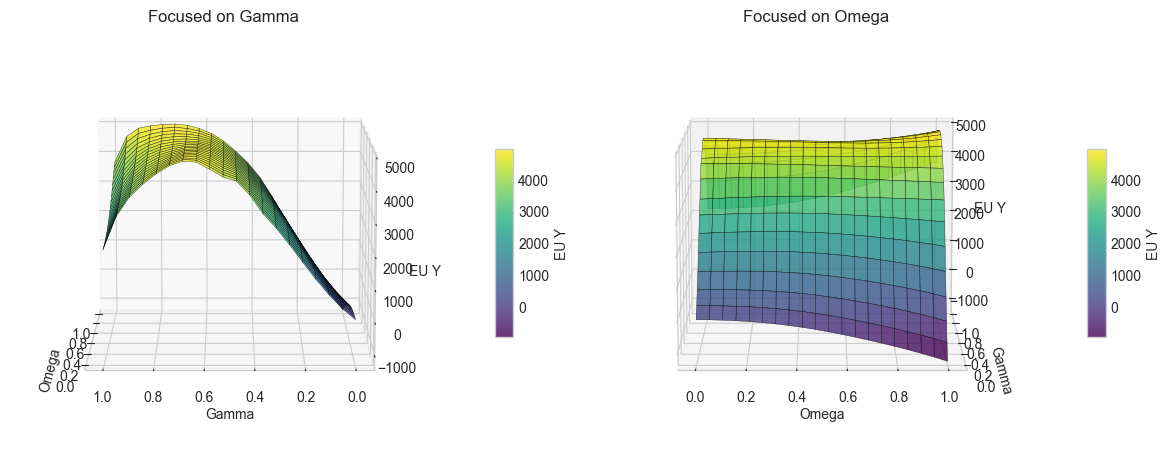

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Filter for theta == 0
df_plot = df_eu_summary[df_eu_summary['theta'] == 0]

# Create grid
omega_vals = np.sort(df_plot['omega'].unique())
gamma_vals = np.sort(df_plot['gamma'].unique())
OMEGA, GAMMA = np.meshgrid(omega_vals, gamma_vals)

# Pivot data into grid
Z = df_plot.pivot(index='gamma', columns='omega', values='Y_EU').values

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

for ax in axes:
    surf = ax.plot_surface(
        OMEGA, GAMMA, Z,
        cmap=CMAP,
        alpha=0.8,
        edgecolor='k',
        linewidth=0.3,
        antialiased=True,
        shade=True,
        lightsource=True
    )
    ax.set_xlabel('Omega')
    ax.set_ylabel('Gamma')
    ax.set_zlabel('EU Y')
    cbar = fig.colorbar(surf, ax=ax, shrink=0.4, aspect=10, pad=0.1)
    cbar.set_label('EU Y')

# Left plot: focused on gamma axis
axes[0].view_init(elev=10, azim=180)
axes[0].set_title('Focused on Gamma')

# Right plot: focused on omega axis
axes[1].view_init(elev=10, azim=270)
axes[1].set_title('Focused on Omega')

plt.tight_layout()
plt.savefig("imgs/3d_graph_eu_output_per_omega_and_gamma.png", dpi=150, bbox_inches="tight")
plt.show()

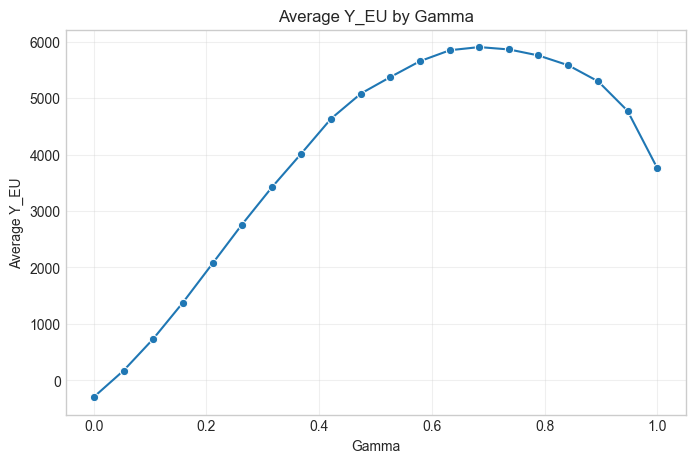

In [12]:
# Plot Y eu per gamma, average all other
df_gamma = df_eu_summary.groupby('gamma')['Y_EU'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_gamma, x='gamma', y='Y_EU', marker='o')
plt.title('Average Y_EU by Gamma')
plt.xlabel('Gamma')
plt.ylabel('Average Y_EU')
plt.grid(True)
plt.show()

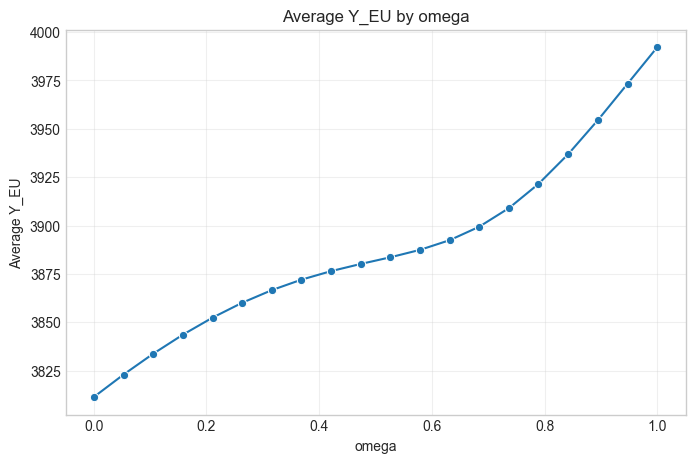

In [13]:
# Plot Y eu per omega, average all other
df_omega = df_eu_summary.groupby('omega')['Y_EU'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_omega, x='omega', y='Y_EU', marker='o')
plt.title('Average Y_EU by omega')
plt.xlabel('omega')
plt.ylabel('Average Y_EU')
plt.grid(True)
plt.show()

## Wedge matrix

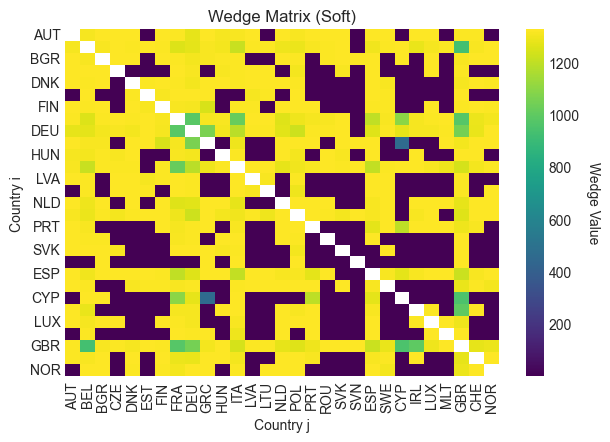

In [14]:
# Plot a wedge matrix across all pairs we have as a heatmap.
df_wedge_soft = pd.read_excel(xls, 'Wedge_SoftPolicy', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_soft.shape[0]):
    df_wedge_soft.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_soft, cmap=CMAP)
plt.title('Wedge Matrix (Soft)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

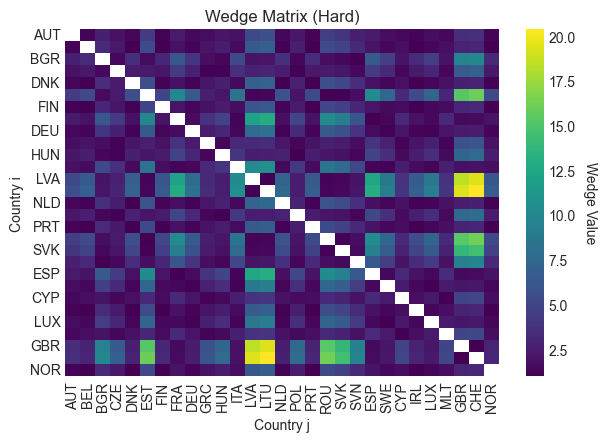

In [15]:
# Plot a wedge matrix across all pairs we have as a heatmap.

df_wedge_hard = pd.read_excel(xls, 'Wedge_Hard', index_col=0)

# Set diagonal to nan since there is nothing to show for this.
for i in range(df_wedge_hard.shape[0]):
    df_wedge_hard.iat[i, i] = np.nan

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_hard, cmap=CMAP)
plt.title('Wedge Matrix (Hard)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

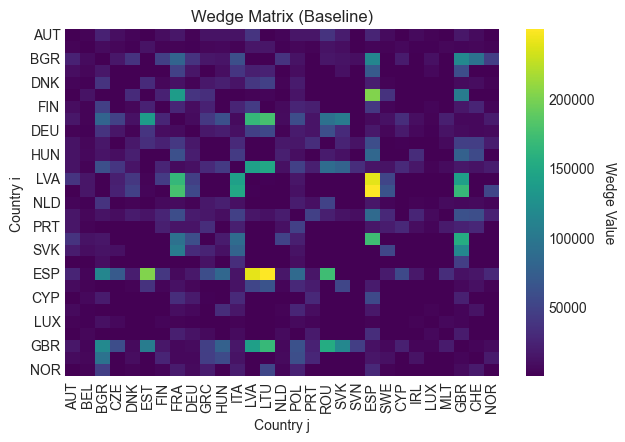

In [16]:
# Wedge baseline

df_wedge_baseline = pd.read_excel(xls, 'Wedge_Baseline', index_col=0)

# Use sns heatmap
plt.figure()
sns.heatmap(df_wedge_baseline, cmap=CMAP)
plt.title('Wedge Matrix (Baseline)')
plt.xlabel('Country j')
plt.ylabel('Country i')
# Add colorbar description
cbar = plt.gcf().axes[-1].set_ylabel('Wedge Value', rotation=270, labelpad=15)
plt.show()

In [17]:
# Get diagonal
diag_wedge = pd.Series(np.diag(df_wedge_baseline), index=df_wedge_baseline.index)
print(diag_wedge.sort_values().head(3))
print("...")
print(diag_wedge.sort_values().tail(3))

SVN    0.022810
DNK    0.121836
HUN    0.142069
dtype: float64
...
DEU    333.937297
GBR    367.341372
ITA    464.374684
dtype: float64


## Gini index across EU across parameters

In [18]:
# We want to analyse how the wedges impact the wealth across the EU countries.

def gini(array):
    """Calculate the Gini coefficient of a numpy array."""
    # Based on bottom eq: http://www.statsdirect.com/help/generatedimages/equations/equation154.svg
    # All values are treated equally, arrays must be 1d:
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)  # Values cannot be negative
    array += 0.0000001  # Values cannot be 0
    array = np.sort(array)  # Sort smallest to largest
    index = np.arange(1, array.shape[0] + 1)  # Index per array element
    n = array.shape[0]  # Number of array elements
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [19]:
# Run without extrenes
exclude = ["IRL", "LUX", "CHE", "SVK", "CYP", "MLT"]
df_output_country_EU_extr = df_output_country_EU[~df_output_country_EU['country'].isin(exclude)]

### Output (Y)

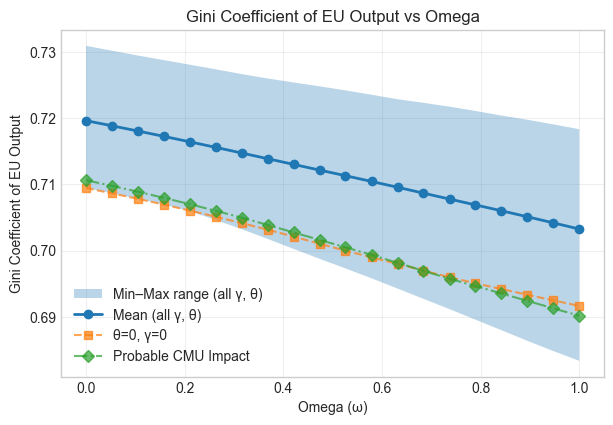

In [20]:
# x-axis: omega
# y-axis: gini index with uncertainty band (min/max across gamma, theta)

# Calculate gini statistics for output for each unique omega
gini_stats_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_omega.append({
        'omega': omega,
        'gini': gini_value
    })

gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# Compute min/max gini across all (gamma, theta) combinations for each omega
gini_minmax_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    
    gini_values = []
    for gamma in subset['gamma'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_omega.append({
            'omega': omega,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all γ, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all γ, θ)', color='C0')
# Overlay the specific case (θ=0, γ=0)
plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# Overlay line for most probable case (θ=CMU_THETA, γ=CMU_GAMMA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
most_probable = most_probable.groupby('omega')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Omega (ω)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Omega')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

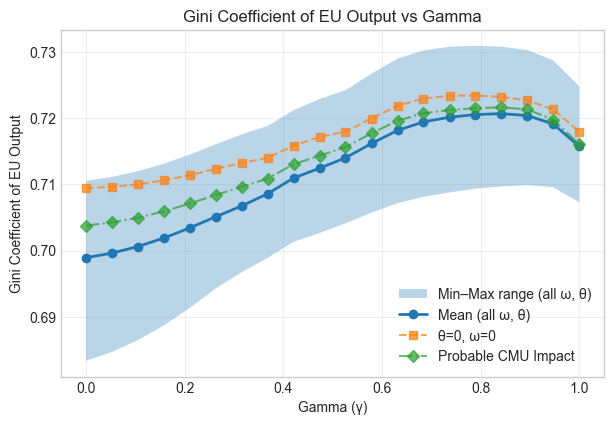

In [21]:
# x-axis: gamma
# y-axis: gini index with uncertainty band (min/max across omega, theta)

# Calculate gini statistics for output for each unique gamma
gini_stats_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_gamma.append({
        'gamma': gamma,
        'gini': gini_value
    })

gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# Compute min/max gini across all (omega, theta) combinations for each gamma
gini_minmax_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_gamma.append({
            'gamma': gamma,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, θ)', color='C0')
# Overlay the specific case (θ=0, ω=0)
plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# Overlay line for most probable case (θ=CMU_THETA, omega=CMU_OMEGA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
most_probable = most_probable.groupby('gamma')['y_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Gamma (γ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Gamma')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

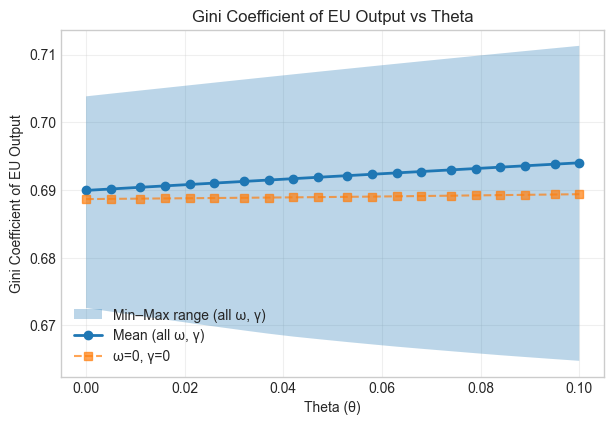

In [22]:
# x-axis: theta
# y-axis: gini index with uncertainty band (min/max across omega, gamma)

# Calculate gini statistics for output for each unique theta
gini_stats_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['y_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_theta.append({
        'theta': theta,
        'gini': gini_value
    })

gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# Compute min/max gini across all (omega, gamma) combinations for each theta
gini_minmax_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for gamma in subset['gamma'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
            if len(subsubset) > 0:
                output_values = subsubset['y_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_theta.append({
            'theta': theta,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, γ)')
# Plot mean as line
plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, γ)', color='C0')
# Overlay the specific case (ω=0, γ=0)
plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

plt.xlabel('Theta (θ)')
plt.ylabel('Gini Coefficient of EU Output')
plt.title('Gini Coefficient of EU Output vs Theta')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
# Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
    lambda subset: gini(subset['y_cmu'].values),
    include_groups=False
).reset_index(name='gini')

print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
print(gini_3d_df.head(10))

3D Gini dataframe shape: (8000, 4)
Gini range: [0.6648, 0.7113]
   omega  gamma  theta      gini
0    0.0    0.0  0.000  0.688659
1    0.0    0.0  0.005  0.688690
2    0.0    0.0  0.011  0.688726
3    0.0    0.0  0.016  0.688756
4    0.0    0.0  0.021  0.688787
5    0.0    0.0  0.026  0.688817
6    0.0    0.0  0.032  0.688854
7    0.0    0.0  0.037  0.688884
8    0.0    0.0  0.042  0.688914
9    0.0    0.0  0.047  0.688948


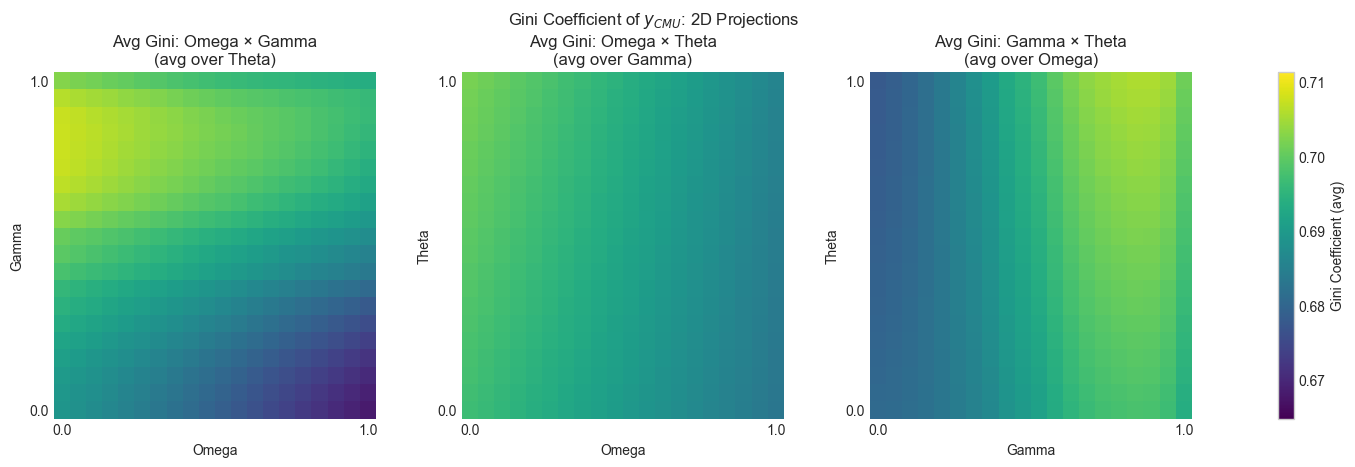

In [24]:
# 2D heatmap projections of Gini across parameter pairs
# Each heatmap averages the Gini over the third (omitted) parameter
# Contour isolines added on top

projection_configs = [
    ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
    ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
    ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
]

gini_vmin = gini_3d_df['gini'].min()
gini_vmax = gini_3d_df['gini'].max()
gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
fig = plt.figure(figsize=(16, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

N_CONTOURS = 7

for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
    pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        vmin=gini_vmin,
        vmax=gini_vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()

    # Show only min and max tick labels on each axis
    n_x = pivot.shape[1]
    n_y = pivot.shape[0]
    ax.set_xticks([0.5, n_x - 0.5])
    ax.set_xticklabels(['0.0', '1.0'])
    ax.set_yticks([0.5, n_y - 0.5])
    ax.set_yticklabels(['0.0', '1.0'])

    # Overlay contour isolines
    # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
    x_centres = np.arange(0.5, n_x)
    y_centres = np.arange(0.5, n_y)
    Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
    # cs = ax.contour(
    #     x_centres, y_centres, Z,
    #     levels=N_CONTOURS,
    #     colors='white',
    #     linewidths=0.5,
    #     alpha=0.75,
    # )
    # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# Colorbar in its own dedicated axes
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

plt.suptitle('Gini Coefficient of $y_{CMU}$: 2D Projections', y=1.02)
plt.show()

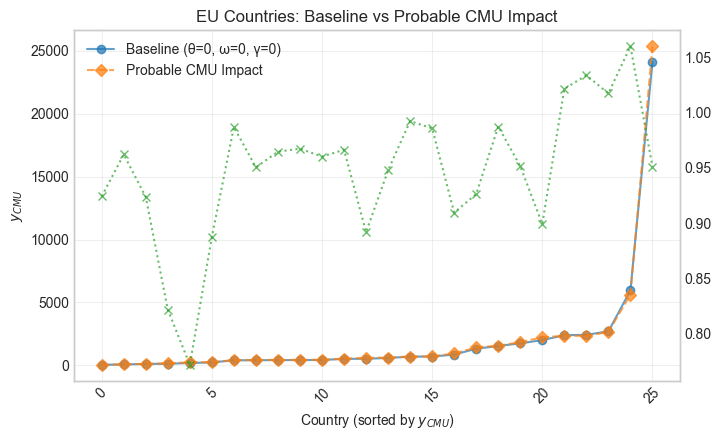

In [25]:
# Plot ln Y for best and worst. Sorting by 
# ln Y. So we line plot and see how the curve
# changes for baseline and most probable case.

baseline = df_output_country_EU[(df_output_country_EU['theta'] == 0) & (df_output_country_EU['omega'] == 0) & (df_output_country_EU['gamma'] == 0)]
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA) & (df_output_country_EU['gamma'] == CMU_GAMMA)]

# Sort by y_cmu
baseline = baseline.sort_values('y_cmu')
most_probable = most_probable.sort_values('y_cmu')

# # Log
# baseline['y_cmu'] = np.log(baseline['y_cmu'])
# most_probable['y_cmu'] = np.log(most_probable['y_cmu'])

plt.figure()
# Baseline
plt.plot(baseline['y_cmu'].values, marker='o', linestyle='-', linewidth=1.5, label='Baseline (θ=0, ω=0, γ=0)', color='C0', alpha=0.7)
# Most probable case
plt.plot(most_probable['y_cmu'].values, marker='D', linestyle='--', linewidth=1.5, label='Probable CMU Impact', color='C1', alpha=0.7)
plt.xlabel('Country (sorted by $y_{CMU}$)')
plt.ylabel('$y_{CMU}$')
plt.title('EU Countries: Baseline vs Probable CMU Impact')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()

# second axis plot difference
plt.twinx().plot(baseline['y_cmu'].values / most_probable['y_cmu'].values, marker='x', linestyle=':', linewidth=1.5, label='Difference (Baseline - Probable)', color='C2', alpha=0.7)
plt.savefig("imgs/eu_output_baseline_vs_probable_cmu.png", dpi=150, bbox_inches="tight")
plt.show()

### Foreign Investment (K)

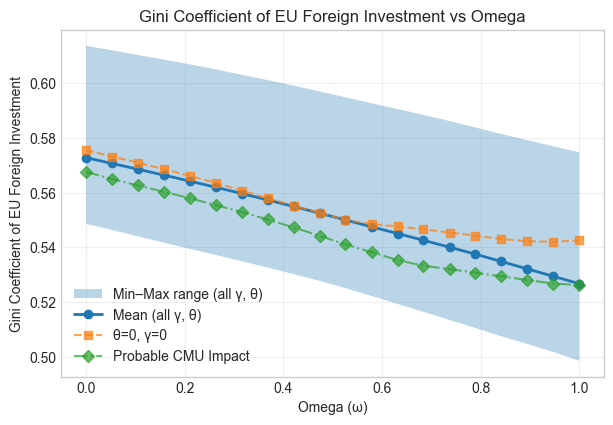

In [26]:
# x-axis: omega
# y-axis: gini index with uncertainty band (min/max across gamma, theta)

# Calculate gini statistics for output for each unique omega
gini_stats_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_omega.append({
        'omega': omega,
        'gini': gini_value
    })

gini_by_omega_df = pd.DataFrame(gini_stats_by_omega)
gini_by_omega_df = gini_by_omega_df.sort_values('omega')

# Compute min/max gini across all (gamma, theta) combinations for each omega
gini_minmax_by_omega = []
for omega in sorted(df_output_country_EU['omega'].unique()):
    subset = df_output_country_EU[df_output_country_EU['omega'] == omega]
    
    gini_values = []
    for gamma in subset['gamma'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['gamma'] == gamma) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_omega.append({
            'omega': omega,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_omega).sort_values('omega')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['omega'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all γ, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['omega'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all γ, θ)', color='C0')
# Overlay the specific case (θ=0, γ=0)
plt.plot(gini_by_omega_df['omega'], gini_by_omega_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, γ=0', color='C1', alpha=0.7)
# Overlay line for most probable case (θ=CMU_THETA, γ=CMU_GAMMA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['gamma'] == CMU_GAMMA)].copy()
most_probable = most_probable.groupby('omega')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['omega'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Omega (ω)')
plt.ylabel('Gini Coefficient of EU Foreign Investment')
plt.title('Gini Coefficient of EU Foreign Investment vs Omega')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("imgs/gini_foreign_investment_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()

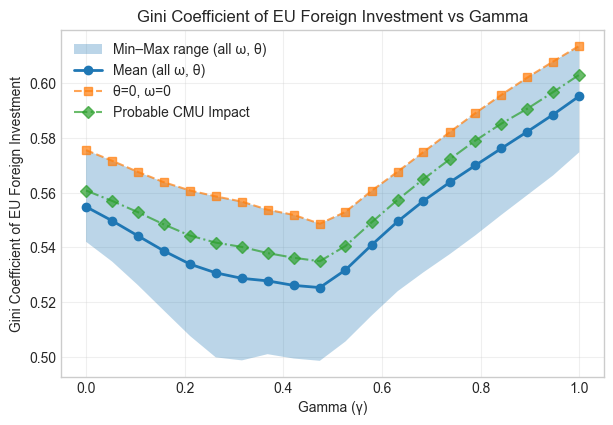

In [27]:
# x-axis: gamma
# y-axis: gini index with uncertainty band (min/max across omega, theta)

# Calculate gini statistics for output for each unique gamma
gini_stats_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    subset = subset[subset['theta'] == 0]  # Focus on no TFP case
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_gamma.append({
        'gamma': gamma,
        'gini': gini_value
    })

gini_by_gamma_df = pd.DataFrame(gini_stats_by_gamma)
gini_by_gamma_df = gini_by_gamma_df.sort_values('gamma')

# Compute min/max gini across all (omega, theta) combinations for each gamma
gini_minmax_by_gamma = []
for gamma in sorted(df_output_country_EU['gamma'].unique()):
    subset = df_output_country_EU[df_output_country_EU['gamma'] == gamma]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for theta in subset['theta'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['theta'] == theta)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_gamma.append({
            'gamma': gamma,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_gamma).sort_values('gamma')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['gamma'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, θ)')
# Plot mean as line
plt.plot(gini_minmax_df['gamma'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, θ)', color='C0')
# Overlay the specific case (θ=0, ω=0)
plt.plot(gini_by_gamma_df['gamma'], gini_by_gamma_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='θ=0, ω=0', color='C1', alpha=0.7)

# Overlay line for most probable case (θ=CMU_THETA, omega=CMU_OMEGA)
most_probable = df_output_country_EU[(df_output_country_EU['theta'] == CMU_THETA) & (df_output_country_EU['omega'] == CMU_OMEGA)]
most_probable = most_probable.groupby('gamma')['k_cmu'].apply(lambda x: gini(x.values)).reset_index(name='gini')
plt.plot(most_probable['gamma'], most_probable['gini'], marker='D', linestyle='-.', 
         linewidth=1.5, label="Probable CMU Impact", color='C2', alpha=0.7)

plt.xlabel('Gamma (γ)')
plt.ylabel('Gini Coefficient of EU Foreign Investment')
plt.title('Gini Coefficient of EU Foreign Investment vs Gamma')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("imgs/gini_foreign_investment_vs_gamma.png", dpi=150, bbox_inches="tight")
plt.show()

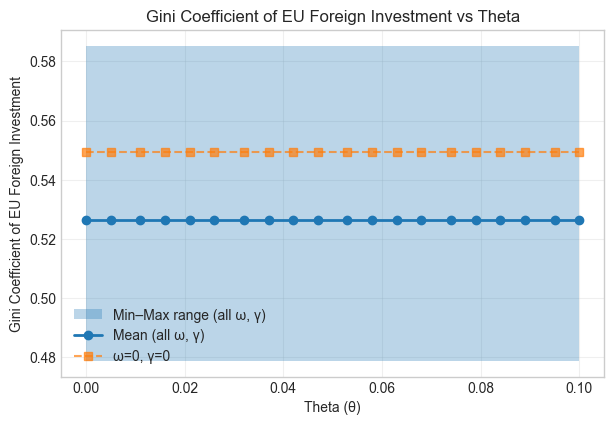

In [28]:
# x-axis: theta
# y-axis: gini index with uncertainty band (min/max across omega, gamma)

# Calculate gini statistics for output for each unique theta
gini_stats_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    subset = subset[subset['omega'] == 0]  # Focus on omega = 0 case
    subset = subset[subset['gamma'] == 0]  # Focus on gamma = 0 case
    
    output_values = subset['k_cmu'].values
    gini_value = gini(output_values)
    gini_stats_by_theta.append({
        'theta': theta,
        'gini': gini_value
    })

gini_by_theta_df = pd.DataFrame(gini_stats_by_theta)
gini_by_theta_df = gini_by_theta_df.sort_values('theta')

# Compute min/max gini across all (omega, gamma) combinations for each theta
gini_minmax_by_theta = []
for theta in sorted(df_output_country['theta'].unique()):
    subset = df_output_country[df_output_country['theta'] == theta]
    
    gini_values = []
    for omega in subset['omega'].unique():
        for gamma in subset['gamma'].unique():
            subsubset = subset[(subset['omega'] == omega) & (subset['gamma'] == gamma)]
            if len(subsubset) > 0:
                output_values = subsubset['k_cmu'].values
                gini_values.append(gini(output_values))
    
    if gini_values:
        gini_minmax_by_theta.append({
            'theta': theta,
            'gini_min': np.min(gini_values),
            'gini_max': np.max(gini_values),
            'gini_mean': np.mean(gini_values)
        })

gini_minmax_df = pd.DataFrame(gini_minmax_by_theta).sort_values('theta')

plt.figure()
# Fill between min and max
plt.fill_between(gini_minmax_df['theta'], gini_minmax_df['gini_min'], gini_minmax_df['gini_max'], 
                 alpha=0.3, label='Min–Max range (all ω, γ)')
# Plot mean as line
plt.plot(gini_minmax_df['theta'], gini_minmax_df['gini_mean'], marker='o', linewidth=2, 
         label='Mean (all ω, γ)', color='C0')
# Overlay the specific case (ω=0, γ=0)
plt.plot(gini_by_theta_df['theta'], gini_by_theta_df['gini'], marker='s', linestyle='--', 
         linewidth=1.5, label='ω=0, γ=0', color='C1', alpha=0.7)

plt.xlabel('Theta (θ)')
plt.ylabel('Gini Coefficient of EU Foreign Investment')
plt.title('Gini Coefficient of EU Foreign Investment vs Theta')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("imgs/gini_foreign_investment_vs_theta.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Build 3D dataframe: compute Gini for all (omega, gamma, theta) combinations

gini_3d_df = df_output_country.groupby(['omega', 'gamma', 'theta']).apply(
    lambda subset: gini(subset['k_cmu'].values),
    include_groups=False
).reset_index(name='gini')

print(f"3D Gini dataframe shape: {gini_3d_df.shape}")
print(f"Gini range: [{gini_3d_df['gini'].min():.4f}, {gini_3d_df['gini'].max():.4f}]")
print(gini_3d_df.head(10))

3D Gini dataframe shape: (8000, 4)
Gini range: [0.4788, 0.5852]
   omega  gamma  theta     gini
0    0.0    0.0  0.000  0.54927
1    0.0    0.0  0.005  0.54927
2    0.0    0.0  0.011  0.54927
3    0.0    0.0  0.016  0.54927
4    0.0    0.0  0.021  0.54927
5    0.0    0.0  0.026  0.54927
6    0.0    0.0  0.032  0.54927
7    0.0    0.0  0.037  0.54927
8    0.0    0.0  0.042  0.54927
9    0.0    0.0  0.047  0.54927


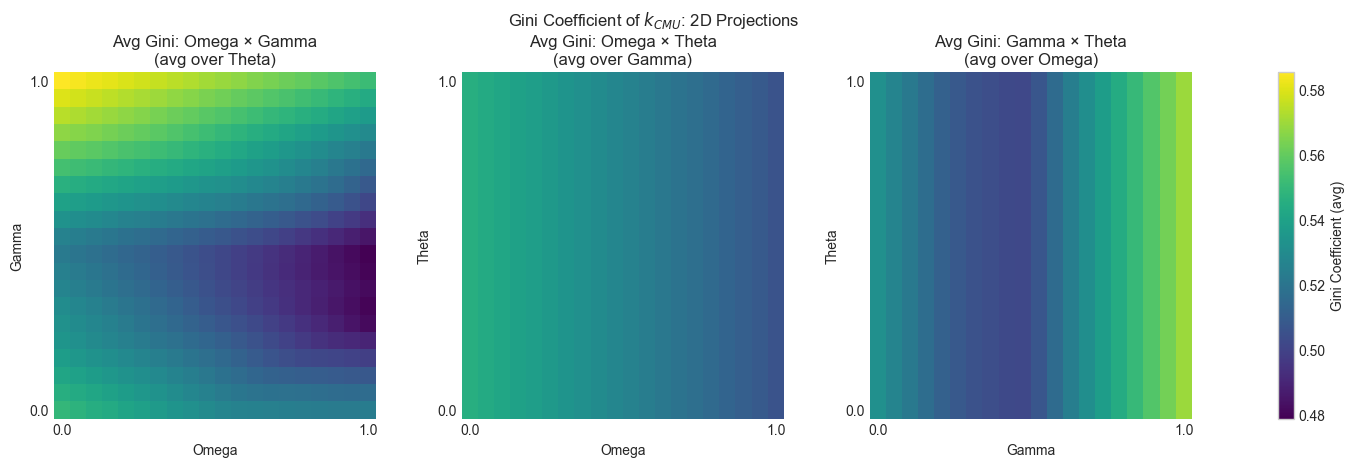

In [30]:
# 2D heatmap projections of Gini across parameter pairs
# Each heatmap averages the Gini over the third (omitted) parameter
# Contour isolines added on top

projection_configs = [
    ('omega', 'gamma', 'theta', 'Omega', 'Gamma',  'Avg Gini: Omega × Gamma\n(avg over Theta)'),
    ('omega', 'theta', 'gamma', 'Omega', 'Theta',  'Avg Gini: Omega × Theta\n(avg over Gamma)'),
    ('gamma', 'theta', 'omega', 'Gamma', 'Theta',  'Avg Gini: Gamma × Theta\n(avg over Omega)'),
]

gini_vmin = gini_3d_df['gini'].min()
gini_vmax = gini_3d_df['gini'].max()
gini_norm = plt.Normalize(gini_vmin, gini_vmax)

# Use gridspec: 3 equal heatmap cols + 1 narrow colorbar col
fig = plt.figure(figsize=(16, 4.5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax  = fig.add_subplot(gs[0, 3])

N_CONTOURS = 7

for ax, (x_col, y_col, avg_col, xlabel, ylabel, title) in zip(axes, projection_configs):
    pivot = gini_3d_df.groupby([y_col, x_col])['gini'].mean().unstack()
    sns.heatmap(
        pivot,
        ax=ax,
        cmap=CMAP,
        cbar=False,
        xticklabels=False,
        yticklabels=False,
        vmin=gini_vmin,
        vmax=gini_vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_yaxis()

    # Show only min and max tick labels on each axis
    n_x = pivot.shape[1]
    n_y = pivot.shape[0]
    ax.set_xticks([0.5, n_x - 0.5])
    ax.set_xticklabels(['0.0', '1.0'])
    ax.set_yticks([0.5, n_y - 0.5])
    ax.set_yticklabels(['0.0', '1.0'])

    # Overlay contour isolines
    # heatmap cells are centred at 0.5, 1.5, ..., so use cell-centre coordinates
    x_centres = np.arange(0.5, n_x)
    y_centres = np.arange(0.5, n_y)
    Z = pivot.values  # rows = y_col, cols = x_col (already inverted by invert_yaxis)
    # cs = ax.contour(
    #     x_centres, y_centres, Z,
    #     levels=N_CONTOURS,
    #     colors='white',
    #     linewidths=0.5,
    #     alpha=0.75,
    # )
    # ax.clabel(cs, inline=True, fontsize=7, fmt='%.4f')

# Colorbar in its own dedicated axes
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=gini_norm)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Gini Coefficient (avg)')

plt.suptitle('Gini Coefficient of $k_{CMU}$: 2D Projections', y=1.02)
plt.savefig("imgs/gini_2d_heatmap_projections.png", dpi=150, bbox_inches="tight")
plt.show()

## Financials per Country

In [31]:
# Plot histogram of stock market cap across the countries
df_final = pd.read_csv("Data/Clean/Final-v4.csv")
df_final

,iso3_i,iso3_j,year,total_pip_million_usd_i,total_pip_million_usd_j,a_ij,r_i,r_j,Y_i,k_i,...,legal_origin,language_proximity,lang_share,lang_official,legal_origin_i,legal_origin_j,fta_wto,d_ling,eu_i,eu_j
0,ABW,ABW,2000,NaN,NaN,NaN,NaN,NaN,3982.696289,11437.366211,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,ABW,ABW,2001,NaN,NaN,NaN,NaN,NaN,3918.971436,11965.093750,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,ABW,ABW,2002,NaN,NaN,NaN,NaN,NaN,3923.781006,12594.469727,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,ABW,ABW,2003,NaN,NaN,NaN,NaN,NaN,3944.353027,13318.708008,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,ABW,ABW,2004,NaN,NaN,NaN,NaN,NaN,4243.611328,14101.028320,...,1.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535269,ZWE,ZWE,2021,NaN,NaN,NaN,NaN,NaN,44440.199219,110979.773438,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535270,ZWE,ZWE,2022,NaN,NaN,NaN,NaN,NaN,47147.550781,114134.882812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535271,ZWE,ZWE,2023,NaN,NaN,NaN,NaN,NaN,49685.757812,118669.257812,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0
1535272,ZWE,ZWE,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0


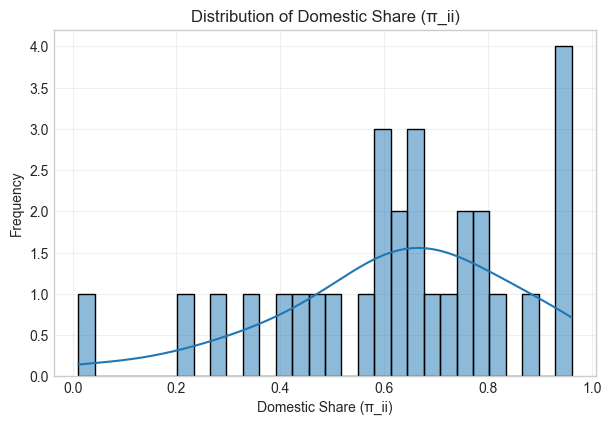

Countries with Domestic Share (π_ii) below 0.2:
['MLT']


In [32]:
# Plot home bias across countries
# Home bias = pi_ii (share of domestic holdings in total portfolio)

df_portfolio = pd.read_excel(xls, 'Portfolio_Data', index_col=0)
df_portfolio_arr = df_portfolio.values
# Flatten with numpy, get full matrix flat
portfolio_flat = df_portfolio_arr.flatten()
# Attach index (iso3_i, iso3_j) and make into series
portfolio_series = pd.Series(portfolio_flat, index=pd.MultiIndex.from_product([df_portfolio.index, df_portfolio.columns], names=['iso3_i', 'iso3_j']))

# Plot distribution of home bias (pi_ii)
home_bias = portfolio_series[portfolio_series.index.get_level_values('iso3_i') == portfolio_series.index.get_level_values('iso3_j')]
home_bias = home_bias.dropna()

plt.figure()
sns.histplot(home_bias, bins=30, kde=True)
plt.title('Distribution of Domestic Share (π_ii)')
plt.xlabel('Domestic Share (π_ii)')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("imgs/domestic_share_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the countries with below 0.2 in Domestic Share
low_home_bias = home_bias[home_bias < 0.2]
print("Countries with Domestic Share (π_ii) below 0.2:")
print(low_home_bias.index.get_level_values('iso3_i').unique().tolist())

## Map

In [33]:
world = gpd.read_file("Data/europe.geo.json")
world.head()

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_id,fclass_pl,fclass_gr,fclass_it,fclass_nl,fclass_se,fclass_bd,fclass_ua,filename,geometry
0,Admin-0 country,5,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,USA.geojson,"MULTIPOLYGON (((-132.74688 56.52568, -132.7576..."
1,Admin-0 country,1,2,France,FR1,1,2,Country,1,France,...,None,None,None,None,None,None,None,None,FRA.geojson,"MULTIPOLYGON (((9.48037 42.80542, 9.4542 42.65..."
2,Admin-0 country,1,3,Ukraine,UKR,0,2,Sovereign country,1,Ukraine,...,None,None,None,None,None,None,None,None,UKR.geojson,"MULTIPOLYGON (((38.21436 47.09146, 38.17832 47..."
3,Admin-0 country,1,4,Belarus,BLR,0,2,Sovereign country,1,Belarus,...,None,None,None,None,None,None,None,None,BLR.geojson,"POLYGON ((31.76338 52.10107, 31.57373 52.10811..."
4,Admin-0 country,3,5,Lithuania,LTU,0,2,Sovereign country,1,Lithuania,...,None,None,None,None,None,None,None,None,LTU.geojson,"MULTIPOLYGON (((20.95781 55.27891, 20.8998 55...."


In [34]:
# Use pycountry to get the iso3 codes
import pycountry

# PyCountry mapping
records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })
    
# Add Unites States of America as USA
records.append({
    "country_name": "United States of America",
    "iso3": "USA",
    "iso2": "US"
})

df_iso = pd.DataFrame(records)
# # Limit it to COUNTRIES
# df_iso_countries = df_iso[df_iso['iso3'].isin(COUNTRIES)]
# Set if in EU27
df_iso['in_EU27'] = df_iso['iso3'].apply(lambda x: 1 if x in EU27 else 0)
print(df_iso.shape)

(250, 5)


In [35]:
# Join world and df_iso_countries on admin and country name
world = world.merge(df_iso, left_on='sovereignt', right_on='country_name', how='left')
# Remove Iceland, it ruins the visualisation
world = world[world["sovereignt"] != "Iceland"]
world_eu = world[world['in_EU27'] == 1]
world_noneu = world[(world['in_EU27'] == 0) & (world['sovereignt'] != 'United States of America')]
world["in_EU27"] = world["in_EU27"].fillna(0).astype(int)
world.head(2)

,featurecla,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,tlc,admin,...,fclass_se,fclass_bd,fclass_ua,filename,geometry,country_name,iso3,iso2,iso_numeric,in_EU27
0,Admin-0 country,5,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,USA.geojson,"MULTIPOLYGON (((-132.74688 56.52568, -132.7576...",United States of America,USA,US,NaN,0
1,Admin-0 country,1,2,France,FR1,1,2,Country,1,France,...,None,None,None,FRA.geojson,"MULTIPOLYGON (((9.48037 42.80542, 9.4542 42.65...",France,FRA,FR,250,1


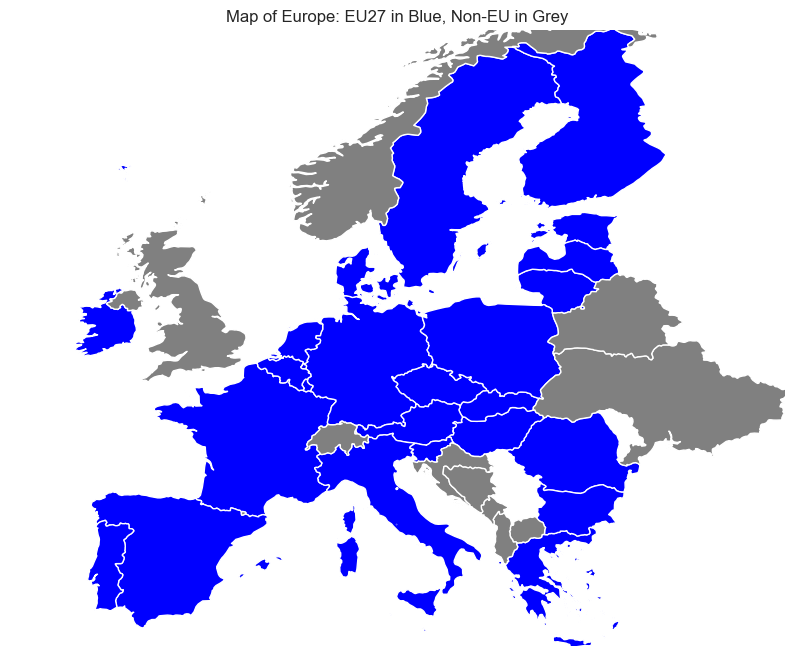

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

world_eu.plot(ax=ax, color='blue', edgecolor='white', autolim=False)
world_noneu.plot(ax=ax, color='gray', edgecolor='white', autolim=False)

ax.set_title('Map of Europe: EU27 in Blue, Non-EU in Grey')
ax.set_aspect('auto')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)

plt.savefig("imgs/map_europe_eu27.png", dpi=150, bbox_inches="tight")
plt.show()

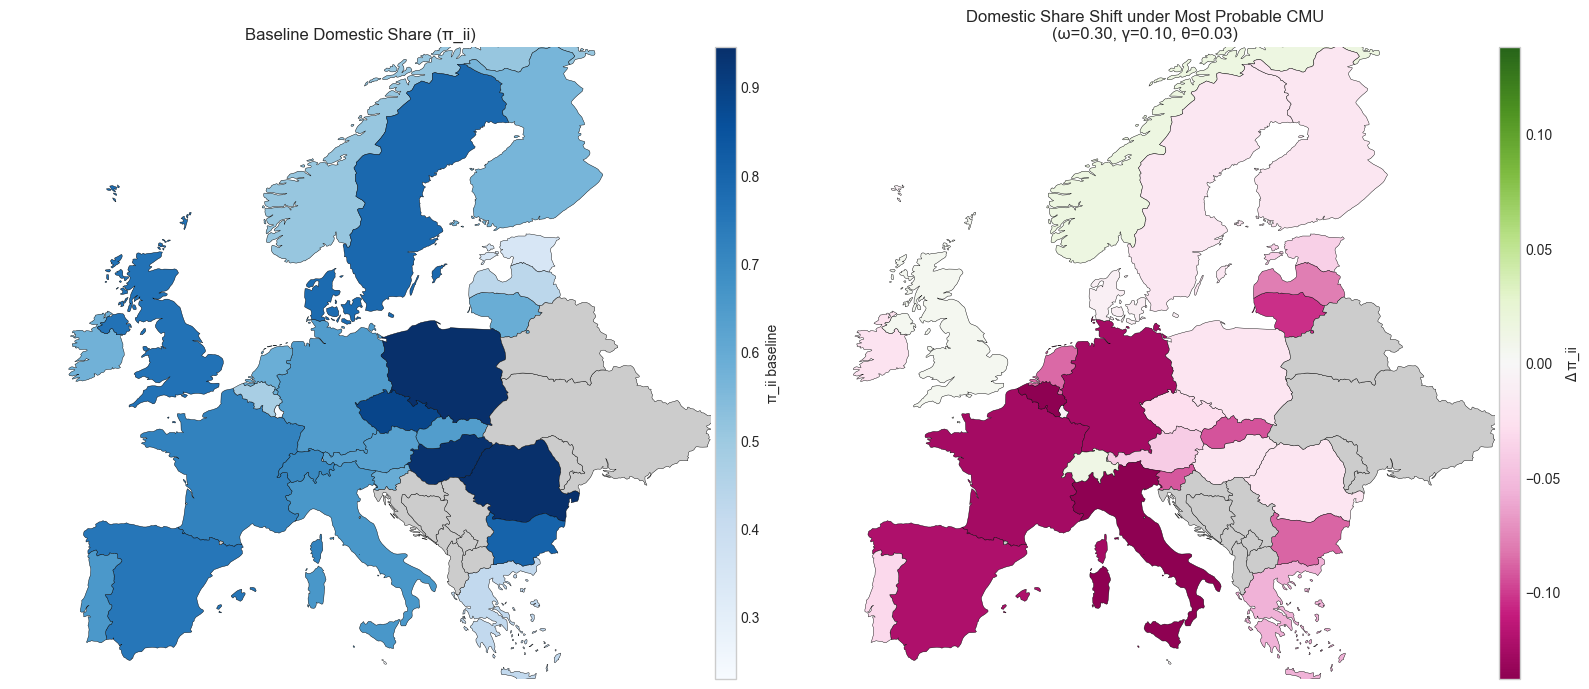

In [37]:
# Map: Domestic Share — baseline level (left) and shift under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_hb = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
][['country', 'pi_home_baseline', 'pi_home_cmu', 'd_pi_home', 'd_pi_home_pct']].copy()

world_hb = world.merge(df_hb, left_on='iso3', right_on='country', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#dbf4ff'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline Domestic Share level ──────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_hb['pi_home_baseline'].quantile(0.05)
vmax_b = world_hb['pi_home_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_hb.plot(ax=ax, column='pi_home_baseline', cmap='Blues',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_hb['pi_home_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('π_ii baseline')

ax.set_title('Baseline Domestic Share (π_ii)')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

# ── Right: shift Δπ_ii under most probable CMU ──────────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_hb['d_pi_home'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_hb.plot(ax=ax, column='d_pi_home', cmap='PiYG',
                 edgecolor='black', linewidth=0.3, legend=False,
                 norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_hb['d_pi_home'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ π_ii')

ax.set_title(f'Domestic Share Shift under Most Probable CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig("imgs/map_domestic_share.png", dpi=150, bbox_inches="tight")
plt.show()

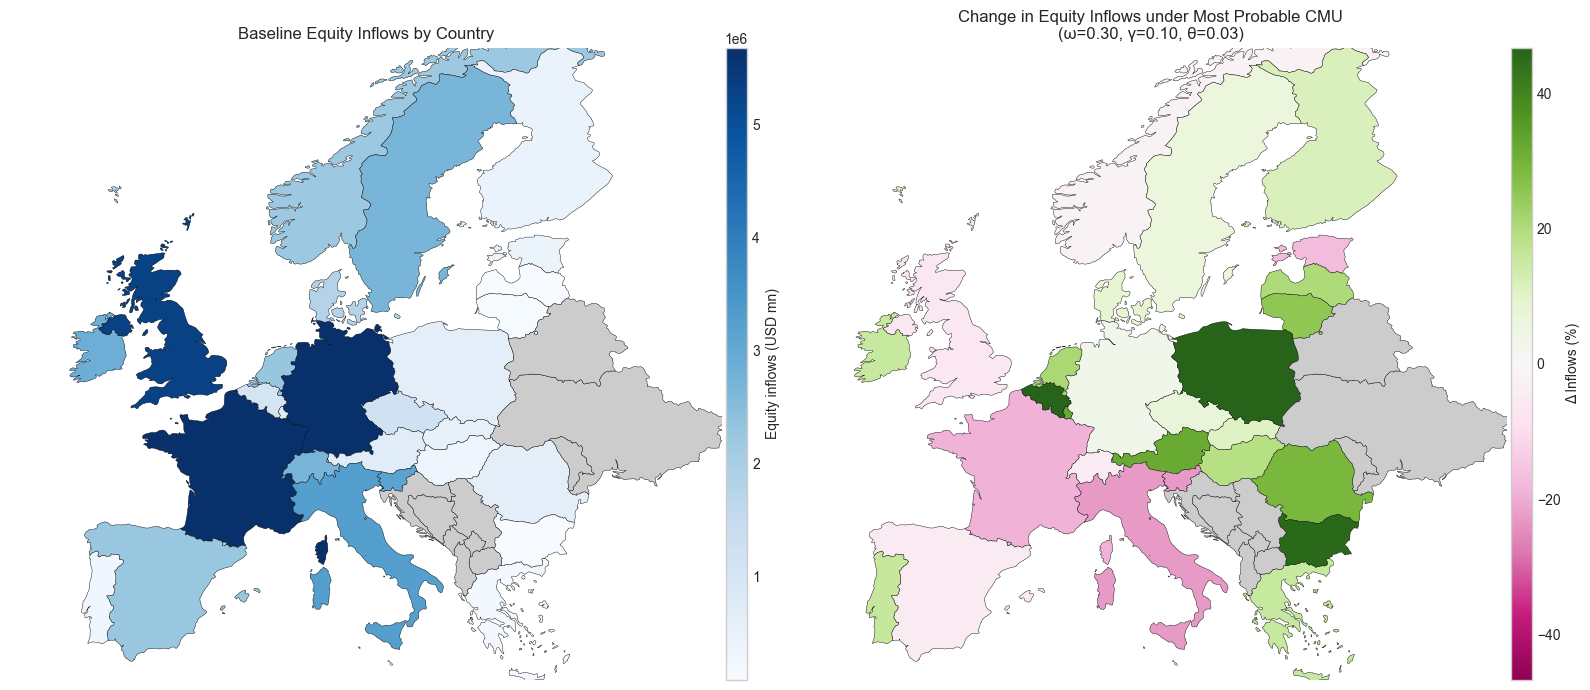

In [38]:
# Map: Flow of money change — baseline inflows (left) and shift under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_flows = pd.read_excel(xls, 'Portfolio_Flows')

# Total equity inflows received by each destination country j
# baseline scenario = omega=0, gamma=0
df_baseline_flows = (
    df_flows[df_flows['scenario'] == 'baseline']
    .groupby('iso3_j')['k_flow'].sum()
    .reset_index()
    .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_baseline'})
)

df_prob_flows = (
    df_flows[df_flows['scenario'] == 'most_probable']
    .groupby('iso3_j')['k_flow'].sum()
    .reset_index()
    .rename(columns={'iso3_j': 'country', 'k_flow': 'k_inflow_cmu'})
)

df_flow_change = df_baseline_flows.merge(df_prob_flows, on='country')
df_flow_change['dk_inflow']     = df_flow_change['k_inflow_cmu'] - df_flow_change['k_inflow_baseline']
df_flow_change['dk_inflow_pct'] = df_flow_change['dk_inflow'] / df_flow_change['k_inflow_baseline'] * 100

world_flow = world.merge(df_flow_change, left_on='iso3', right_on='country', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline total inflows ─────────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_flow['k_inflow_baseline'].quantile(0.05)
vmax_b = world_flow['k_inflow_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_flow.plot(ax=ax, column='k_inflow_baseline', cmap='Blues',
                   edgecolor='black', linewidth=0.3, legend=False,
                   norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_flow['k_inflow_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('Equity inflows (USD mn)')

ax.set_title('Baseline Equity Inflows by Country')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

# ── Right: shift in inflows under most probable CMU ──────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_flow['dk_inflow_pct'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_flow.plot(ax=ax, column='dk_inflow_pct', cmap='PiYG',
                   edgecolor='black', linewidth=0.3, legend=False,
                   norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_flow['dk_inflow_pct'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ Inflows (%)')

ax.set_title(f'Change in Equity Inflows under Most Probable CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig("imgs/map_equity_inflows.png", dpi=150, bbox_inches="tight")
plt.show()

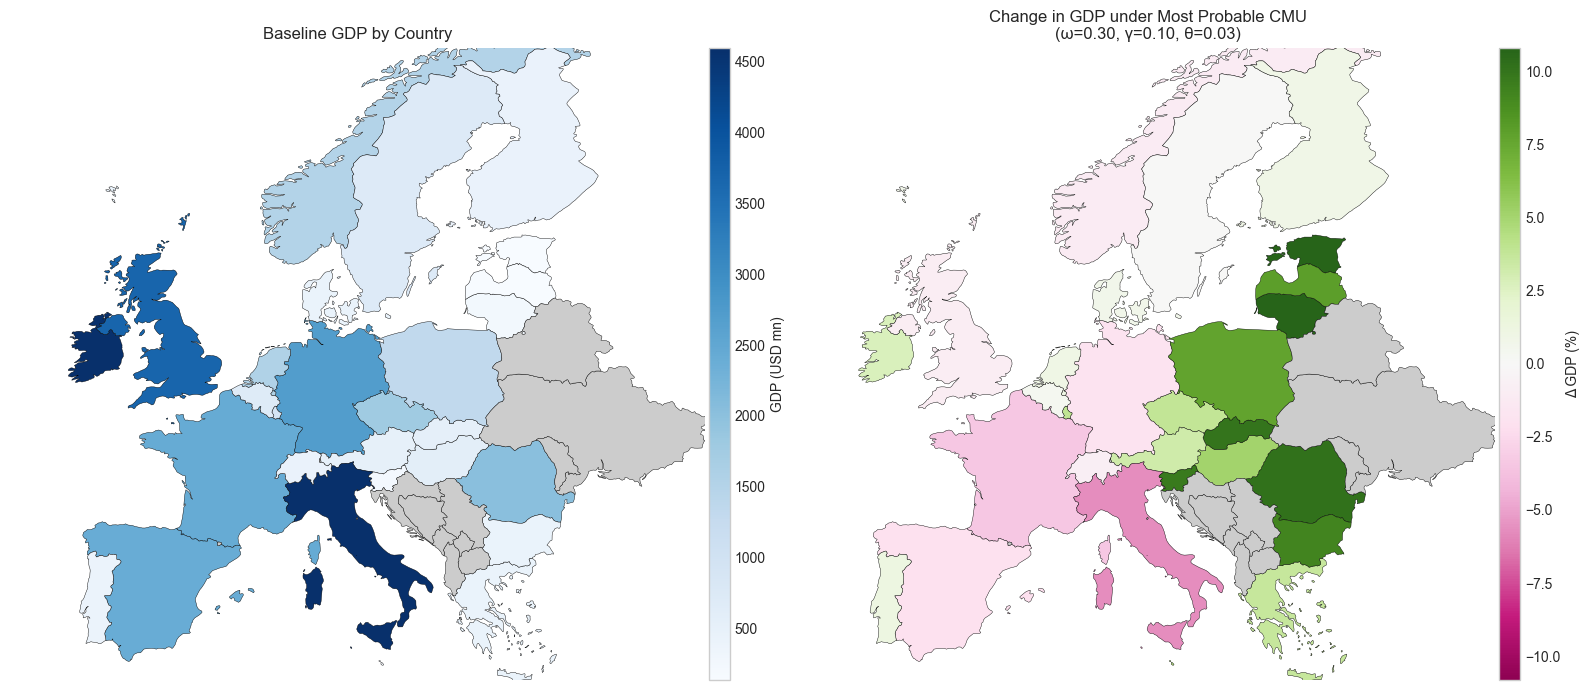

In [39]:
# MAP GDP
# Map: GDP baseline level (left) and % change under most probable CMU (right)
from mpl_toolkits.axes_grid1 import make_axes_locatable

df_gdp_mp = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
] .copy()

df_gdp_mp['dy_pct'] = (df_gdp_mp['y_cmu'] - df_gdp_mp['y_baseline']) / df_gdp_mp['y_baseline'] * 100

world_gdp = world.merge(
    df_gdp_mp[['country', 'y_baseline', 'dy_pct']],
    left_on='iso3', right_on='country', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

_WATER   = '#a8d8ea'
_MISSING = dict(color='#cccccc', edgecolor='black', label='No data')

# ── Left: baseline GDP ───────────────────────────────────────
ax = axes[0]
ax.set_facecolor(_WATER)

vmin_b = world_gdp['y_baseline'].quantile(0.05)
vmax_b = world_gdp['y_baseline'].quantile(0.95)
norm_b = plt.Normalize(vmin=vmin_b, vmax=vmax_b)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_gdp.plot(ax=ax, column='y_baseline', cmap='Blues',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_b, missing_kwds=_MISSING)

sm_b = plt.cm.ScalarMappable(cmap='Blues', norm=norm_b)
sm_b.set_array(world_gdp['y_baseline'].dropna().values)
div_b = make_axes_locatable(ax)
cax_b = div_b.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_b, cax=cax_b).set_label('GDP (USD mn)')

ax.set_title('Baseline GDP by Country')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

# ── Right: % change in GDP under most probable CMU ───────────
ax = axes[1]
ax.set_facecolor(_WATER)

vlim = world_gdp['dy_pct'].abs().quantile(0.95)
norm_d = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

world_noneu.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
world_gdp.plot(ax=ax, column='dy_pct', cmap='PiYG',
                  edgecolor='black', linewidth=0.3, legend=False,
                  norm=norm_d, missing_kwds=_MISSING)

sm_d = plt.cm.ScalarMappable(cmap='PiYG', norm=norm_d)
sm_d.set_array(world_gdp['dy_pct'].dropna().values)
div_d = make_axes_locatable(ax)
cax_d = div_d.append_axes("right", size="3%", pad=0.04)
fig.colorbar(sm_d, cax=cax_d).set_label('Δ GDP (%)')

ax.set_title(f'Change in GDP under Most Probable CMU\n(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.set_axis_off()
ax.set_xlim(-15, 40)
ax.set_ylim(35, 70)
ax.set_aspect('auto')

plt.tight_layout()
plt.savefig("imgs/map_gdp.png", dpi=150, bbox_inches="tight")
plt.show()

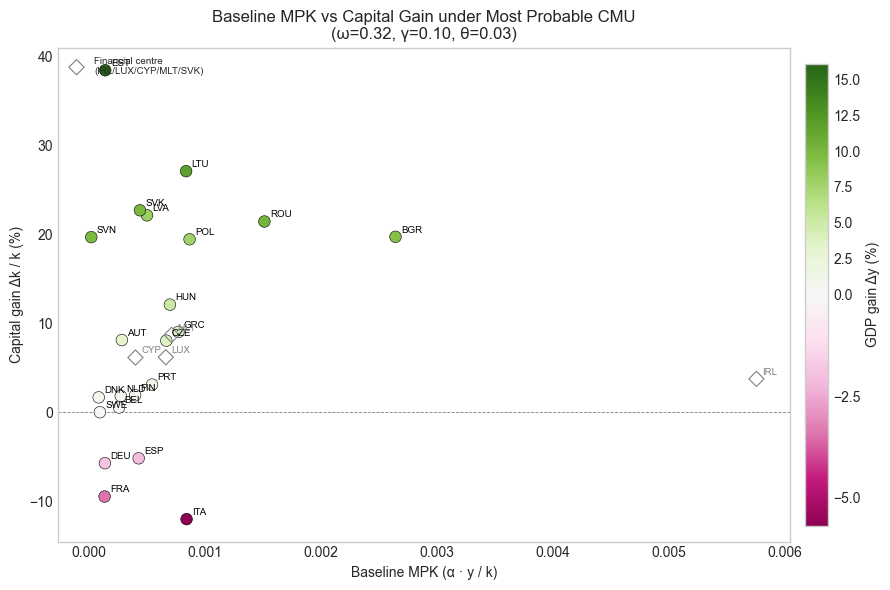

In [ ]:
# Scatter: baseline MPK vs capital gain under most probable CMU
# Each point = one EU27 country; colour = GDP gain (dy_pct)

df_scatter = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
][['country', 'mpk_baseline', 'dk_pct', 'dy_pct', 'dA_pct', 'is_financial_ctr']].copy()

# Separate financial centres (distorted data) from regular countries
df_main = df_scatter[df_scatter['is_financial_ctr'] == 0]
df_fc   = df_scatter[df_scatter['is_financial_ctr'] == 1]

fig, ax = plt.subplots(figsize=(9, 6))

# Colour by dy_pct
vmin_c = df_main['dy_pct'].min()
vmax_c = df_main['dy_pct'].max()
norm_c = mcolors.TwoSlopeNorm(vmin=vmin_c, vcenter=0, vmax=vmax_c)
cmap_c = plt.cm.PiYG

sc = ax.scatter(
    df_main['mpk_baseline'],
    df_main['dk_pct'],
    c=df_main['dy_pct'],
    cmap=cmap_c,
    norm=norm_c,
    s=70,
    zorder=3,
    edgecolors='black',
    linewidths=0.4,
)

# Plot financial centres as hollow grey markers
ax.scatter(
    df_fc['mpk_baseline'],
    df_fc['dk_pct'],
    c='none',
    edgecolors='grey',
    linewidths=0.8,
    s=60,
    zorder=3,
    label='Financial centre\n(IRL/LUX/CYP/MLT/SVK)',
    marker='D',
)

# Country labels
for _, row in df_scatter.iterrows():
    ax.annotate(
        row['country'],
        xy=(row['mpk_baseline'], row['dk_pct']),
        xytext=(4, 3),
        textcoords='offset points',
        fontsize=7,
        color='grey' if row['is_financial_ctr'] else 'black',
    )

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)

cb = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('GDP gain Δy (%)')

ax.set_xlabel('Baseline MPK (α · y / k)')
ax.set_ylabel('Capital gain Δk / k (%)')
ax.set_title(f'Baseline MPK vs Capital Gain under Most Probable CMU\n'
             f'(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig("imgs/scatter_mpk_vs_capital_gain.png", dpi=150, bbox_inches="tight")
plt.show()

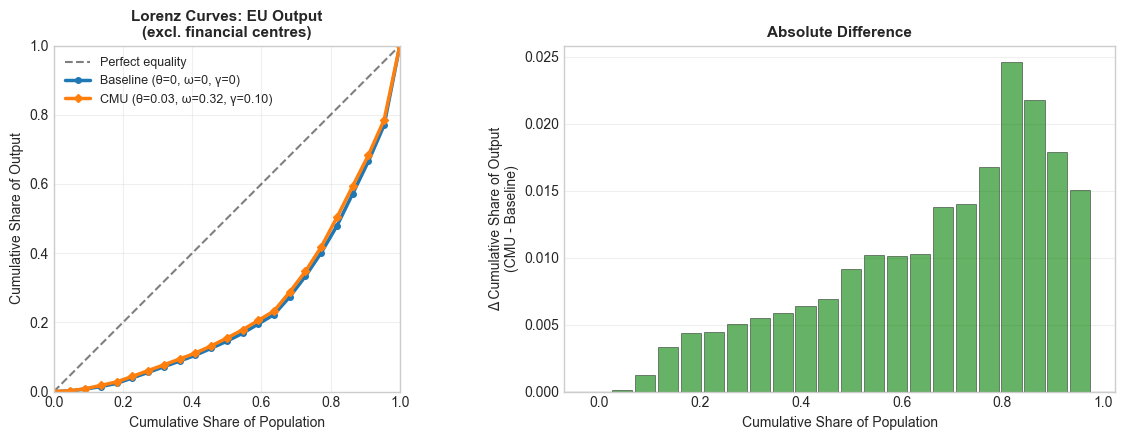

Gini Coefficient (Baseline): 0.5220
Gini Coefficient (Most Probable CMU): 0.5032
Change in Gini: -0.0188

Max absolute difference in cumulative output: 0.0246 at pop share 0.82
Mean absolute difference: 0.0094


In [ ]:
# Lorenz curve: baseline vs most probable CMU scenario
# Financial centres excluded from distributional analysis
FINANCIAL_CENTRES = ["IRL", "LUX", "CYP", "MLT"]
df_eu_excl = df_output_country_EU[~df_output_country_EU['country'].isin(FINANCIAL_CENTRES)].copy()

def lorenz_curve(values):
    """Return (cum_population_share, cum_wealth_share) for a Lorenz curve."""
    values = np.sort(np.array(values, dtype=float))
    cum_wealth = np.cumsum(values) / values.sum()
    cum_pop = np.arange(1, len(values) + 1) / len(values)
    # Prepend origin
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_wealth])

baseline      = df_eu_excl[(df_eu_excl['theta'] == 0) & (df_eu_excl['omega'] == 0) & (df_eu_excl['gamma'] == 0)]
most_probable = df_eu_excl[(df_eu_excl['theta'] == CMU_THETA) & (df_eu_excl['omega'] == CMU_OMEGA) & (df_eu_excl['gamma'] == CMU_GAMMA)]

cum_pop_base, cum_wealth_base = lorenz_curve(baseline['y_cmu'].values)
cum_pop_cmu,  cum_wealth_cmu  = lorenz_curve(most_probable['y_cmu'].values)

# Interpolate to same grid for difference calculation
cum_wealth_cmu_interp = np.interp(cum_pop_base, cum_pop_cmu, cum_wealth_cmu)
wealth_diff = cum_wealth_cmu_interp - cum_wealth_base

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ─── Left: Standard Lorenz Curves ───────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect equality', alpha=0.5)
ax.plot(cum_pop_base, cum_wealth_base, marker='o', linewidth=2.5, 
        label='Baseline (θ=0, ω=0, γ=0)', color='C0', markersize=4)
ax.plot(cum_pop_cmu, cum_wealth_cmu, marker='D', linewidth=2.5, 
        label=f'CMU (θ={_CMU_THETA:.2f}, ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f})', 
        color='C1', markersize=4)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Cumulative Share of Output', fontsize=10)
ax.set_title('Lorenz Curves: EU Output\n(excl. financial centres)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

# ─── Right: Absolute Difference ────────────────────────────
ax = axes[1]
colors = ['red' if d < 0 else 'green' for d in wealth_diff]
ax.bar(cum_pop_base[:-1], wealth_diff[:-1], width=0.04, color=colors, alpha=0.6, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cumulative Share of Population', fontsize=10)
ax.set_ylabel('Δ Cumulative Share of Output\n(CMU - Baseline)', fontsize=10)
ax.set_title('Absolute Difference', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("imgs/lorenz_curves_output.png", dpi=150, bbox_inches="tight")
plt.show()

# Print statistics
gini_baseline = gini(baseline['y_cmu'].values)
gini_cmu = gini(most_probable['y_cmu'].values)
max_diff = np.max(np.abs(wealth_diff))
max_diff_idx = np.argmax(np.abs(wealth_diff))

print(f"Gini Coefficient (Baseline): {gini_baseline:.4f}")
print(f"Gini Coefficient (Most Probable CMU): {gini_cmu:.4f}")
print(f"Change in Gini: {gini_cmu - gini_baseline:+.4f}")
print(f"\nMax absolute difference in cumulative output: {max_diff:.4f} at pop share {cum_pop_base[max_diff_idx]:.2f}")
print(f"Mean absolute difference: {np.mean(np.abs(wealth_diff[:-1])):.4f}")


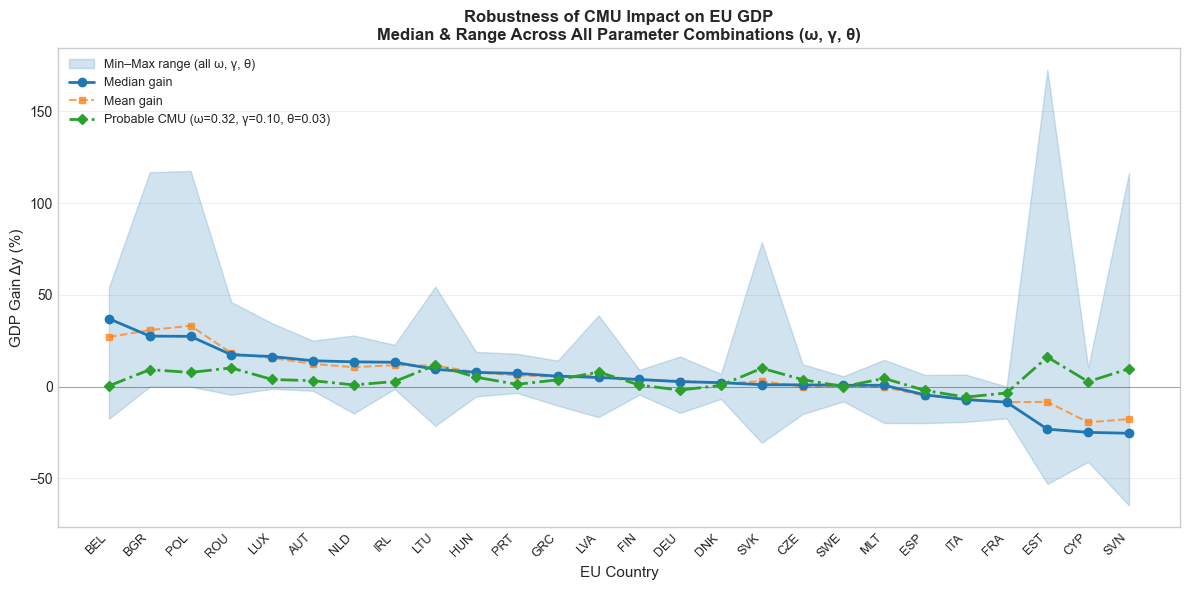

EU GDP Gain Robustness Summary
Country    Probable     Median       Mean         Min          Max          Range       
--------------------------------------------------------------------------------
BEL              0.415%      36.997%      27.002%     -17.501%      54.057%      71.558%
BGR              9.246%      27.528%      30.814%       0.000%     116.748%     116.748%
POL              7.740%      27.387%      33.154%       0.000%     117.458%     117.458%
ROU             10.204%      17.360%      18.259%      -4.435%      46.025%      50.459%
LUX              3.893%      16.395%      15.568%      -1.149%      34.515%      35.664%
AUT              3.240%      14.114%      12.374%      -2.255%      25.051%      27.306%
NLD              0.934%      13.504%      10.602%     -14.572%      27.853%      42.424%
IRL              2.767%      13.285%      11.674%      -1.283%      22.753%      24.036%
LTU             11.744%       9.438%      11.444%     -21.385%      54.436%      75.821

In [ ]:
# Robustness bands: EU GDP gain - median line + min/max band across all omega*gamma*theta combinations

# For each country, calculate GDP gain across all parameter combinations
df_robustness = []

for country in df_output_country_EU['country'].unique():
    country_data = df_output_country_EU[df_output_country_EU['country'] == country]
    
    # Calculate GDP gain percentage for each parameter combination
    country_data_copy = country_data.copy()
    country_data_copy['dy_pct'] = (country_data_copy['y_cmu'] - country_data_copy['y_baseline']) / country_data_copy['y_baseline'] * 100
    
    # Get all unique parameter combinations
    for (omega, gamma, theta), group in country_data_copy.groupby(['omega', 'gamma', 'theta']):
        dy_pct = group['dy_pct'].values[0]
        df_robustness.append({
            'country': country,
            'omega': omega,
            'gamma': gamma,
            'theta': theta,
            'dy_pct': dy_pct
        })

df_robustness = pd.DataFrame(df_robustness)

# Group by country and calculate statistics
robustness_stats = []
for country in sorted(df_robustness['country'].unique()):
    country_gains = df_robustness[df_robustness['country'] == country]['dy_pct']
    
    robustness_stats.append({
        'country': country,
        'dy_median': country_gains.median(),
        'dy_mean': country_gains.mean(),
        'dy_min': country_gains.min(),
        'dy_max': country_gains.max(),
        'dy_std': country_gains.std()
    })

df_stats = pd.DataFrame(robustness_stats).sort_values('dy_median', ascending=False)

# Get most probable case for each country
most_prob_gains = []
for country in sorted(df_output_country_EU['country'].unique()):
    country_data = df_output_country_EU[
        (df_output_country_EU['country'] == country) &
        (df_output_country_EU['theta'] == CMU_THETA) &
        (df_output_country_EU['omega'] == CMU_OMEGA) &
        (df_output_country_EU['gamma'] == CMU_GAMMA)
    ]
    if len(country_data) > 0:
        dy_pct = (country_data['y_cmu'].values[0] - country_data['y_baseline'].values[0]) / country_data['y_baseline'].values[0] * 100
        most_prob_gains.append({'country': country, 'dy_prob': dy_pct})

df_prob = pd.DataFrame(most_prob_gains)
df_stats = df_stats.merge(df_prob, on='country', how='left')

# Plot robustness bands
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_stats))

# Min-max band (light shading)
ax.fill_between(x_pos, df_stats['dy_min'], df_stats['dy_max'], 
                alpha=0.2, color='C0', label='Min–Max range (all ω, γ, θ)')

# Median line
ax.plot(x_pos, df_stats['dy_median'], marker='o', linewidth=2, 
        markersize=6, color='C0', label='Median gain', zorder=3)

# Mean line (optional, dashed)
ax.plot(x_pos, df_stats['dy_mean'], marker='s', linewidth=1.5, 
        markersize=4, linestyle='--', color='C1', alpha=0.7, label='Mean gain', zorder=2)

# Most probable CMU case
ax.plot(x_pos, df_stats['dy_prob'], marker='D', linewidth=2, 
        markersize=5, linestyle='-.', color='C2', label=f"Probable CMU (ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})", zorder=3)

# Horizontal zero line
ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

# Formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(df_stats['country'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('EU Country', fontsize=11)
ax.set_ylabel('GDP Gain Δy (%)', fontsize=11)
ax.set_title('Robustness of CMU Impact on EU GDP\nMedian & Range Across All Parameter Combinations (ω, γ, θ)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9, loc='best')

plt.tight_layout()
plt.savefig("imgs/robustness_bands_gdp_gain.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary statistics
print("EU GDP Gain Robustness Summary")
print("=" * 80)
print(f"{'Country':<10} {'Probable':<12} {'Median':<12} {'Mean':<12} {'Min':<12} {'Max':<12} {'Range':<12}")
print("-" * 80)
for _, row in df_stats.iterrows():
    range_val = row['dy_max'] - row['dy_min']
    print(f"{row['country']:<10} {row['dy_prob']:>11.3f}% {row['dy_median']:>11.3f}% {row['dy_mean']:>11.3f}% {row['dy_min']:>11.3f}% {row['dy_max']:>11.3f}% {range_val:>11.3f}%")
print("-" * 80)

In [ ]:
# ── DIVE 1: Full decomposition table for all EU27 (no financial centres) ──
import os; os.makedirs("dive", exist_ok=True); os.makedirs("imgs", exist_ok=True)

FOCUS = ["FIN", "SWE", "DEU", "BEL", "DNK", "FRA"]
EU27_NO_FC = [c for c in df_output_country_EU['country'].unique()
              if c not in ["CYP", "MLT", "LUX", "IRL"]]

prob = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA) &
    (df_output_country['country'].isin(EU27_NO_FC))
][["country", "dy_pct", "dk_pct", "dk_foreign_pct", "d_pi_home_pct",
   "capital_effect_pct", "tfp_effect_pct", "delta_ii",
   "pi_home_baseline", "pi_home_cmu",
   "k_baseline", "k_foreign_baseline", "f_baseline", "f_cmu",
   "s_total_wealth", "R_normalised"]].sort_values("dy_pct")

print("=" * 110)
print("Full decomposition — EU27 excl. financial centres — most probable CMU (ω={:.3f}, γ={:.3f}, θ={:.3f})".format(
    _CMU_OMEGA, _CMU_GAMMA, _CMU_THETA))
print("=" * 110)
print(f"{'Country':<8} {'dy%':>7} {'dk%':>7} {'dkFor%':>8} {'capEff%':>8} {'tfpEff%':>8} "
      f"{'dπHome%':>8} {'π_base':>8} {'π_cmu':>8} {'δ_ii':>8} {'f_base':>9} {'R_norm':>8}")
print("-" * 110)
for _, r in prob.iterrows():
    print(f"{r['country']:<8} {r['dy_pct']:>7.2f} {r['dk_pct']:>7.2f} {r['dk_foreign_pct']:>8.2f} "
          f"{r['capital_effect_pct']:>8.2f} {r['tfp_effect_pct']:>8.2f} "
          f"{r['d_pi_home_pct']:>8.2f} {r['pi_home_baseline']:>8.4f} {r['pi_home_cmu']:>8.4f} "
          f"{r['delta_ii']:>8.4f} {r['f_baseline']:>9.5f} {r['R_normalised']:>8.3f}")
print("=" * 110)
print()

# Correlation with dy_pct
print("── Correlation with dy_pct ──")
num_cols = ["dk_pct","dk_foreign_pct","d_pi_home_pct","capital_effect_pct",
            "tfp_effect_pct","pi_home_baseline","delta_ii","f_baseline","R_normalised"]
corr = prob[num_cols + ["dy_pct"]].corr()["dy_pct"].drop("dy_pct").sort_values(key=abs, ascending=False)
for k, v in corr.items():
    print(f"  {k:<30}: {v:+.4f}")


Full decomposition — EU27 excl. financial centres — most probable CMU (ω=0.316, γ=0.105, θ=0.032)
Country      dy%     dk%   dkFor%  capEff%  tfpEff%  dπHome%   π_base    π_cmu     δ_ii    f_base   R_norm
--------------------------------------------------------------------------------------------------------------
ITA        -5.70  -12.00    73.39    -5.55     0.05   -23.84   0.6611   0.5035 464.3747   0.02067    0.757
FRA        -3.44   -9.46    57.32    -3.39     0.06   -17.60   0.7208   0.5940 228.5217   0.03372    0.676
ESP        -2.08   -5.16    58.07    -2.10     0.05   -16.20   0.7508   0.6292 129.4833   0.02611    0.732
DEU        -1.90   -5.71    51.36    -1.96     0.11   -19.64   0.6461   0.5192 333.9373   0.06420    0.955
SWE         0.05    0.03     2.77     0.01     0.04    -2.39   0.7896   0.7708   0.2884   0.44024    0.860
BEL         0.41    0.56    51.64     0.23     0.19   -32.41   0.4781   0.3231  26.5440   0.11483    0.765
DNK         0.70    1.70     5.27     0.63

In [44]:
# ── DIVE 2: Portfolio flow decomposition — who sends/receives capital to FIN & SWE ──
# df_flows is already in memory from the map cell

for COUNTRY in ["FIN", "SWE"]:
    print("=" * 80)
    print(f"COUNTRY: {COUNTRY}")
    print("=" * 80)

    # Inflows: iso3_j == COUNTRY
    in_base = df_flows[(df_flows['iso3_j'] == COUNTRY) & (df_flows['scenario'] == 'baseline')]\
        [['iso3_i', 'k_flow']].rename(columns={'k_flow': 'k_in_base'})
    in_prob = df_flows[(df_flows['iso3_j'] == COUNTRY) & (df_flows['scenario'] == 'most_probable')]\
        [['iso3_i', 'k_flow']].rename(columns={'k_flow': 'k_in_prob'})
    inflows = in_base.merge(in_prob, on='iso3_i', how='outer').fillna(0)
    inflows['dk_in'] = inflows['k_in_prob'] - inflows['k_in_base']
    inflows = inflows.sort_values('dk_in')

    # Outflows: iso3_i == COUNTRY
    out_base = df_flows[(df_flows['iso3_i'] == COUNTRY) & (df_flows['scenario'] == 'baseline')]\
        [['iso3_j', 'k_flow']].rename(columns={'k_flow': 'k_out_base'})
    out_prob = df_flows[(df_flows['iso3_i'] == COUNTRY) & (df_flows['scenario'] == 'most_probable')]\
        [['iso3_j', 'k_flow']].rename(columns={'k_flow': 'k_out_prob'})
    outflows = out_base.merge(out_prob, on='iso3_j', how='outer').fillna(0)
    outflows['dk_out'] = outflows['k_out_prob'] - outflows['k_out_base']
    outflows = outflows.sort_values('dk_out')

    print(f"\n  Total inflows  baseline: {in_base['k_in_base'].sum():>12.1f} USD mn")
    print(f"  Total inflows  CMU:      {in_prob['k_in_prob'].sum():>12.1f} USD mn")
    print(f"  Δ inflows:               {in_prob['k_in_prob'].sum() - in_base['k_in_base'].sum():>+12.1f} USD mn")
    print(f"\n  Total outflows baseline: {out_base['k_out_base'].sum():>12.1f} USD mn")
    print(f"  Total outflows CMU:      {out_prob['k_out_prob'].sum():>12.1f} USD mn")
    print(f"  Δ outflows:              {out_prob['k_out_prob'].sum() - out_base['k_out_base'].sum():>+12.1f} USD mn")

    print(f"\n  ── Top 5 INFLOW LOSERS (countries sending LESS to {COUNTRY} under CMU) ──")
    print(inflows.head(5).to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

    print(f"\n  ── Top 5 INFLOW GAINERS (countries sending MORE to {COUNTRY} under CMU) ──")
    print(inflows.tail(5)[::-1].to_string(index=False, float_format=lambda x: f"{x:10.1f}"))

    print(f"\n  ── Top 5 OUTFLOW CHANGERS (where {COUNTRY} sends MORE under CMU) ──")
    print(outflows.tail(5)[::-1].to_string(index=False, float_format=lambda x: f"{x:10.1f}"))
    print()


COUNTRY: FIN

  Total inflows  baseline:     454272.1 USD mn
  Total inflows  CMU:          508757.7 USD mn
  Δ inflows:                   +54485.6 USD mn

  Total outflows baseline:     622179.4 USD mn
  Total outflows CMU:          622179.4 USD mn
  Δ outflows:                      -0.0 USD mn

  ── Top 5 INFLOW LOSERS (countries sending LESS to FIN under CMU) ──
iso3_i  k_in_base  k_in_prob      dk_in
   FIN   351899.4   331313.5   -20586.0
   IRL    61656.8    59794.0    -1862.8
   GBR     7938.1     6760.2    -1177.9
   CHE      109.5       99.1      -10.4
   NOR       46.7       44.4       -2.3

  ── Top 5 INFLOW GAINERS (countries sending MORE to FIN under CMU) ──
iso3_i  k_in_base  k_in_prob      dk_in
   DEU     9709.1    42358.1    32649.0
   FRA     4739.6    20042.6    15303.0
   ITA     5630.3    17425.9    11795.6
   BEL     3136.4     8908.7     5772.3
   NLD      717.7     5018.7     4301.0

  ── Top 5 OUTFLOW CHANGERS (where FIN sends MORE under CMU) ──
iso3_j  k_out_b

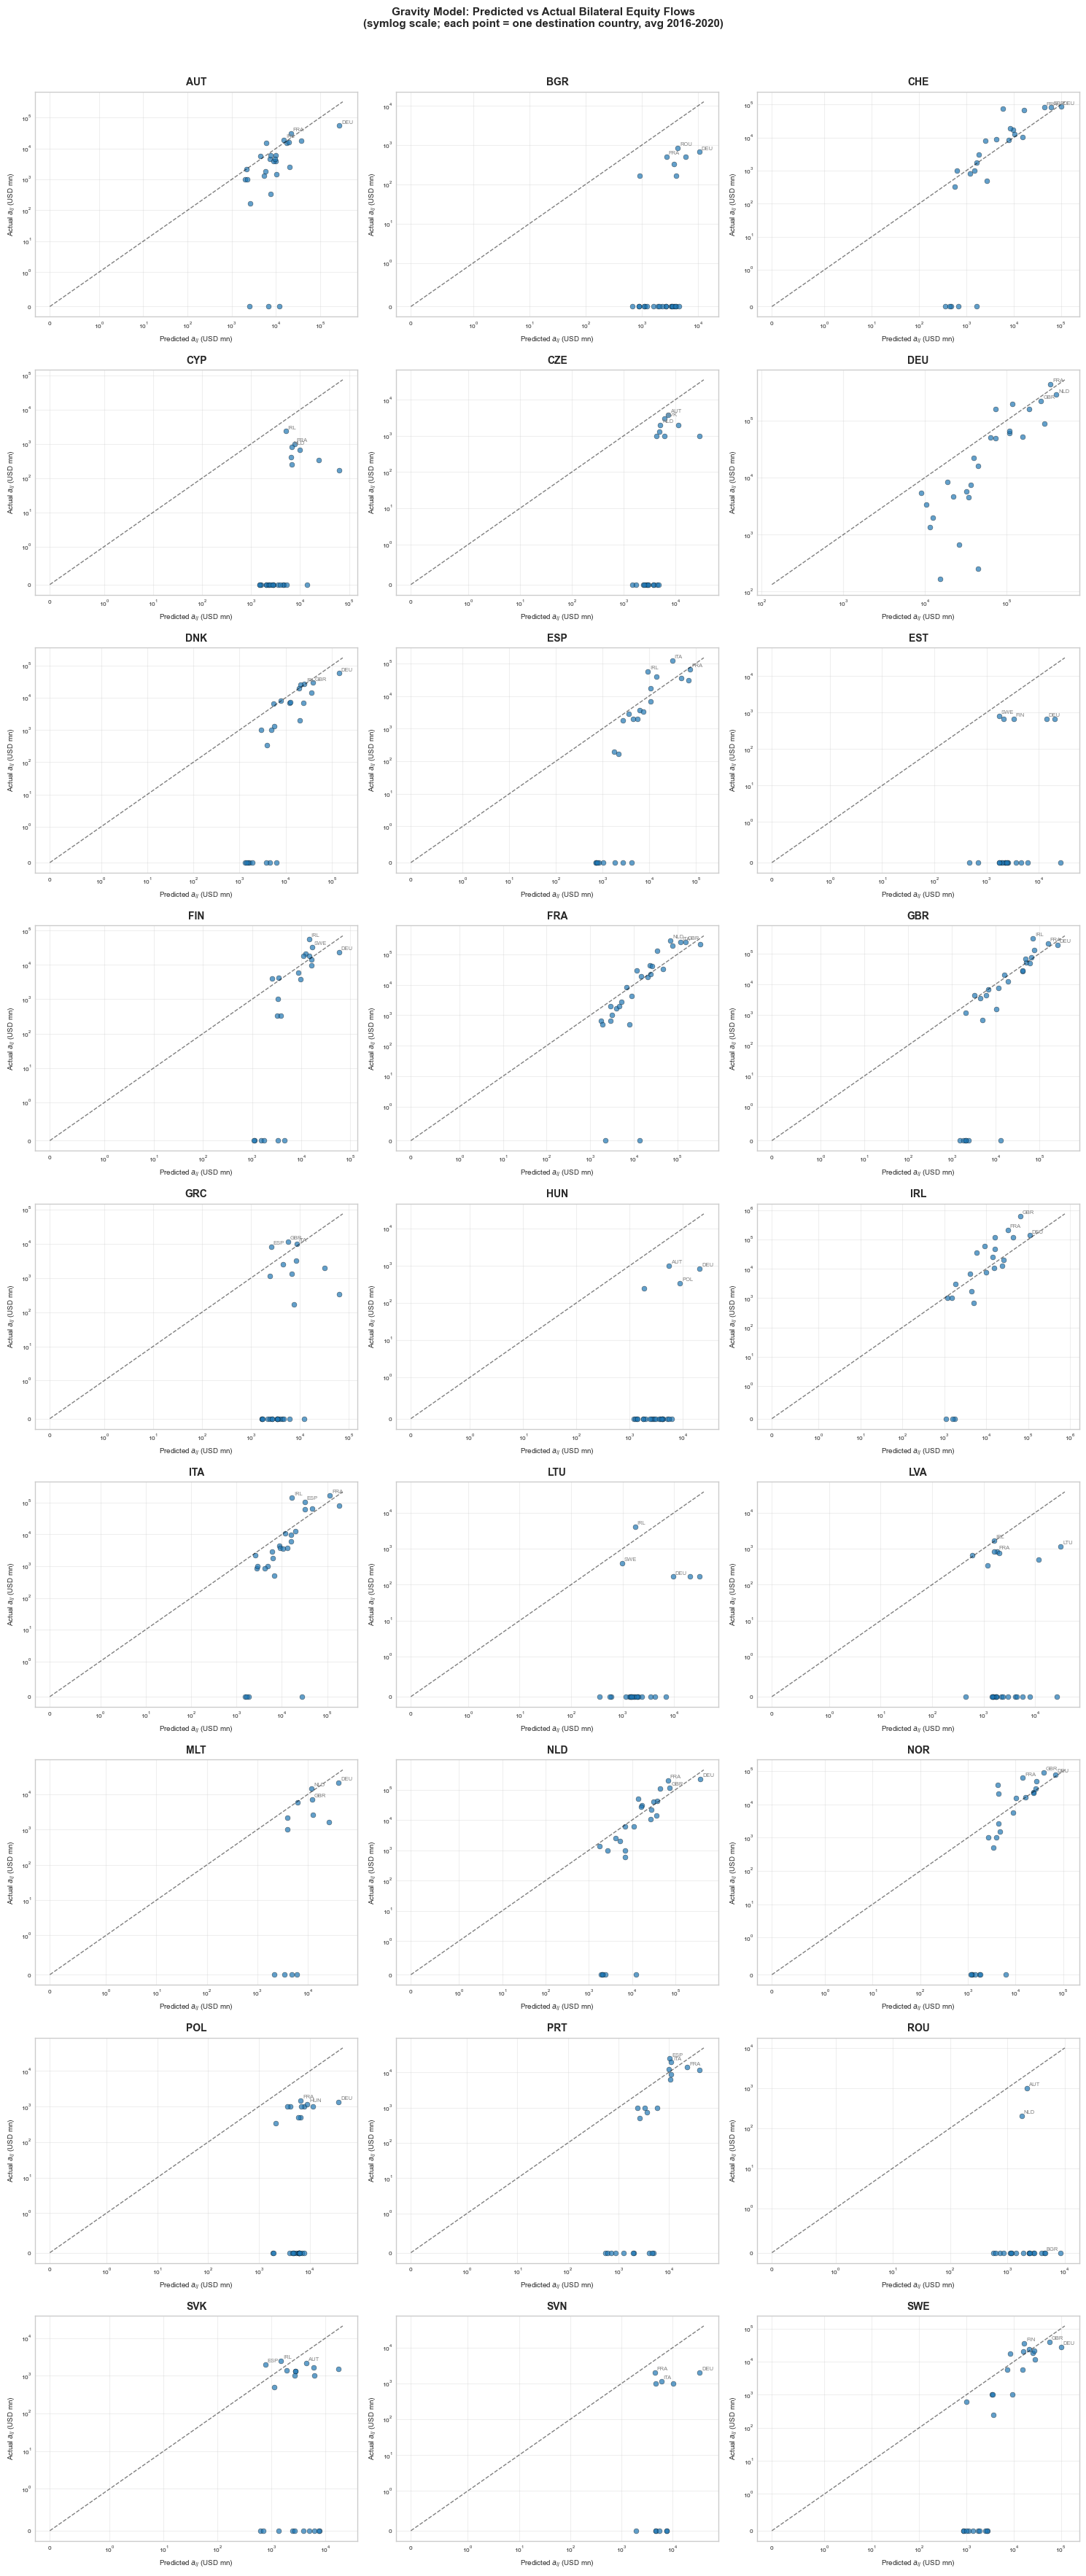

In [60]:
# ── Gravity model: predicted vs actual bilateral flows per source country ──
import math

pred = pd.read_csv("v4-gravity_pred.csv")

# Values in the CSV were divided by 1e6 before fitting; convert back to USD mn
pred["a_ij"]      = pred["a_ij"]      * 1e6
pred["a_ij_pred"] = pred["a_ij_pred"] * 1e6

# Average over years so each (i,j) pair has one point
pred_avg = pred.groupby(["iso3_i", "iso3_j"])[["a_ij", "a_ij_pred"]].mean().reset_index()

countries = sorted(pred_avg["iso3_i"].unique())
n_countries = len(countries)
ncols = 3
nrows = math.ceil(n_countries / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for ax, country in zip(axes, countries):
    sub = pred_avg[pred_avg["iso3_i"] == country].copy()
    
    # Log scale for readability (flows span many orders of magnitude)
    x = sub["a_ij_pred"]
    y = sub["a_ij"]
    
    ax.scatter(x, y, s=25, alpha=0.7, edgecolors="black", linewidths=0.3, color="C0")
    
    # 45-degree perfect-fit line across the data range
    lim_min = min(x.min(), y.min()) * 0.8
    lim_max = max(x.max(), y.max()) * 1.2
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, alpha=0.5, label="y = x")
    
    # Label a few outlier destination points
    for _, row in sub.nlargest(3, "a_ij").iterrows():
        ax.annotate(row["iso3_j"], xy=(row["a_ij_pred"], row["a_ij"]),
                    fontsize=5.5, color="grey", xytext=(2, 2), textcoords="offset points")
    
    ax.set_xscale("symlog", linthresh=1)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_title(country, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted $a_{ij}$ (USD mn)", fontsize=7)
    ax.set_ylabel("Actual $a_{ij}$ (USD mn)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

# Hide unused subplot panels
for ax in axes[n_countries:]:
    ax.set_visible(False)

plt.suptitle("Gravity Model: Predicted vs Actual Bilateral Equity Flows\n"
             "(symlog scale; each point = one destination country, avg 2016-2020)",
             fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("dive/gravity_pred_vs_actual_grid.png", dpi=150, bbox_inches="tight")
plt.show()


# New Visualisations

In [46]:
# Load extra sheets needed for new visualisations
df_mpk        = pd.read_excel(xls, 'MPK_Dispersion')
df_robustness = pd.read_excel(xls, 'Robustness')

print("MPK_Dispersion columns:", list(df_mpk.columns[:6]), "...")
print("Robustness columns:    ", list(df_robustness.columns))
print(f"Robustness rows: {len(df_robustness):,}")


MPK_Dispersion columns: ['country', 'mpk_baseline_theta0.100', 'mpk_om0.000_gm0.000', 'mpk_om0.000_gm0.053', 'mpk_om0.000_gm0.105', 'mpk_om0.000_gm0.158'] ...
Robustness columns:     ['label', 'eta', 'theta', 'omega', 'gamma', 'ΔY_EU/Y_EU (%)', 'Avg ΔHomeBias (EU)']
Robustness rows: 24,000


## 3 · Capital vs TFP decomposition — stacked bars per country

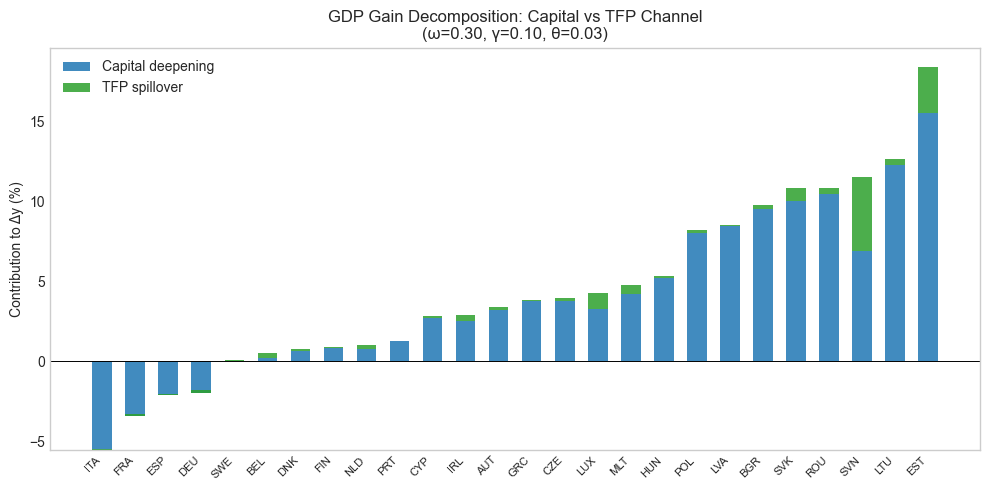

In [62]:
# Stacked bar: capital effect vs TFP effect on EU GDP per country
# Scenario: most probable CMU, with θ > 0 to make TFP visible
CMU_THETA_TFP = thetas[np.argmin(np.abs(thetas - 0.05))]   # use θ≈0.05 so TFP channel is non-zero

df_decomp = df_output_country_EU[
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA) &
    (df_output_country_EU['theta'] == CMU_THETA_TFP)
][['country', 'capital_effect_pct', 'tfp_effect_pct', 'dy_pct']].copy()
df_decomp = df_decomp.sort_values('dy_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_decomp))
w = 0.6

# Capital bars (bottom)
bars_cap = ax.bar(x, df_decomp['capital_effect_pct'], w,
                  label='Capital deepening', color='C0', alpha=0.85)
# TFP bars (stacked on top of capital)
bars_tfp = ax.bar(x, df_decomp['tfp_effect_pct'], w,
                  bottom=df_decomp['capital_effect_pct'],
                  label='TFP spillover', color='C2', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(df_decomp['country'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Contribution to Δy (%)')
ax.set_title(f'GDP Gain Decomposition: Capital vs TFP Channel\n'
             f'(ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.legend()
plt.tight_layout()
plt.savefig("imgs/decomp_capital_vs_tfp.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · θ sensitivity — EU GDP gain vs ω (lines per θ)

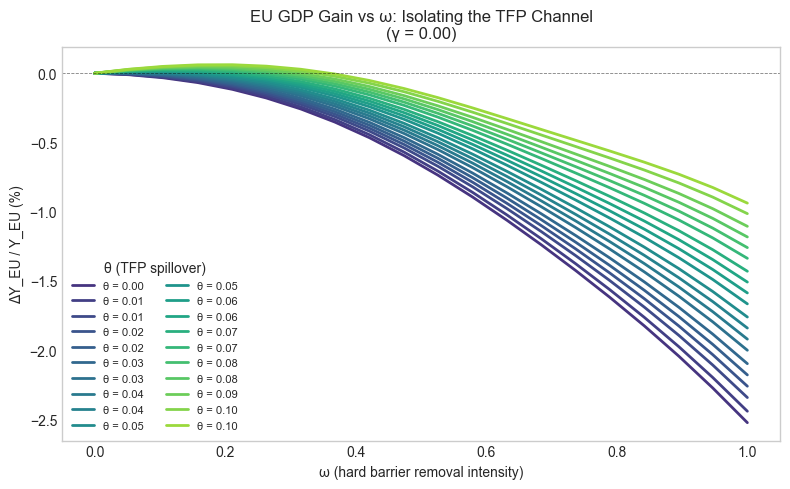

In [48]:
# EU aggregate GDP gain (%) vs ω, one line per θ level
# γ = 0 (hard barriers only) so we isolate the financial integration channel
gamma_fixed = gammas[np.argmin(np.abs(gammas - 0.0))]

df_theta_sens = df_eu_summary[df_eu_summary['gamma'] == gamma_fixed].copy()

# Compute % gain relative to baseline (ω=0, γ=0, θ=0)
baseline_Y = df_eu_summary[
    (df_eu_summary['omega'] == gammas[0]) &
    (df_eu_summary['gamma'] == gammas[0]) &
    (df_eu_summary['theta'] == thetas[0])
]['Y_EU'].values[0]

# Y_EU column is already the delta (Y_EU_cmu - Y_EU_base), so dY_EU_pct is in EU_Summary
# Use dY_EU_pct directly
df_theta_sens = df_eu_summary[df_eu_summary['gamma'] == gamma_fixed].copy()

fig, ax = plt.subplots(figsize=(8, 5))

theta_vals_sorted = sorted(df_theta_sens['theta'].unique())
cmap_t = plt.cm.viridis(np.linspace(0.15, 0.85, len(theta_vals_sorted)))

for color, theta_val in zip(cmap_t, theta_vals_sorted):
    sub = df_theta_sens[df_theta_sens['theta'] == theta_val].sort_values('omega')
    ax.plot(sub['omega'], sub['dY_EU_pct'], linewidth=2, color=color,
            label=f'θ = {theta_val:.2f}')

ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('ω (hard barrier removal intensity)')
ax.set_ylabel('ΔY_EU / Y_EU (%)')
ax.set_title(f'EU GDP Gain vs ω: Isolating the TFP Channel\n(γ = {gamma_fixed:.2f})')
ax.legend(title='θ (TFP spillover)', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("imgs/theta_sensitivity_eu_gdp_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · Δf_i vs ΔA_i scatter — TFP channel validation

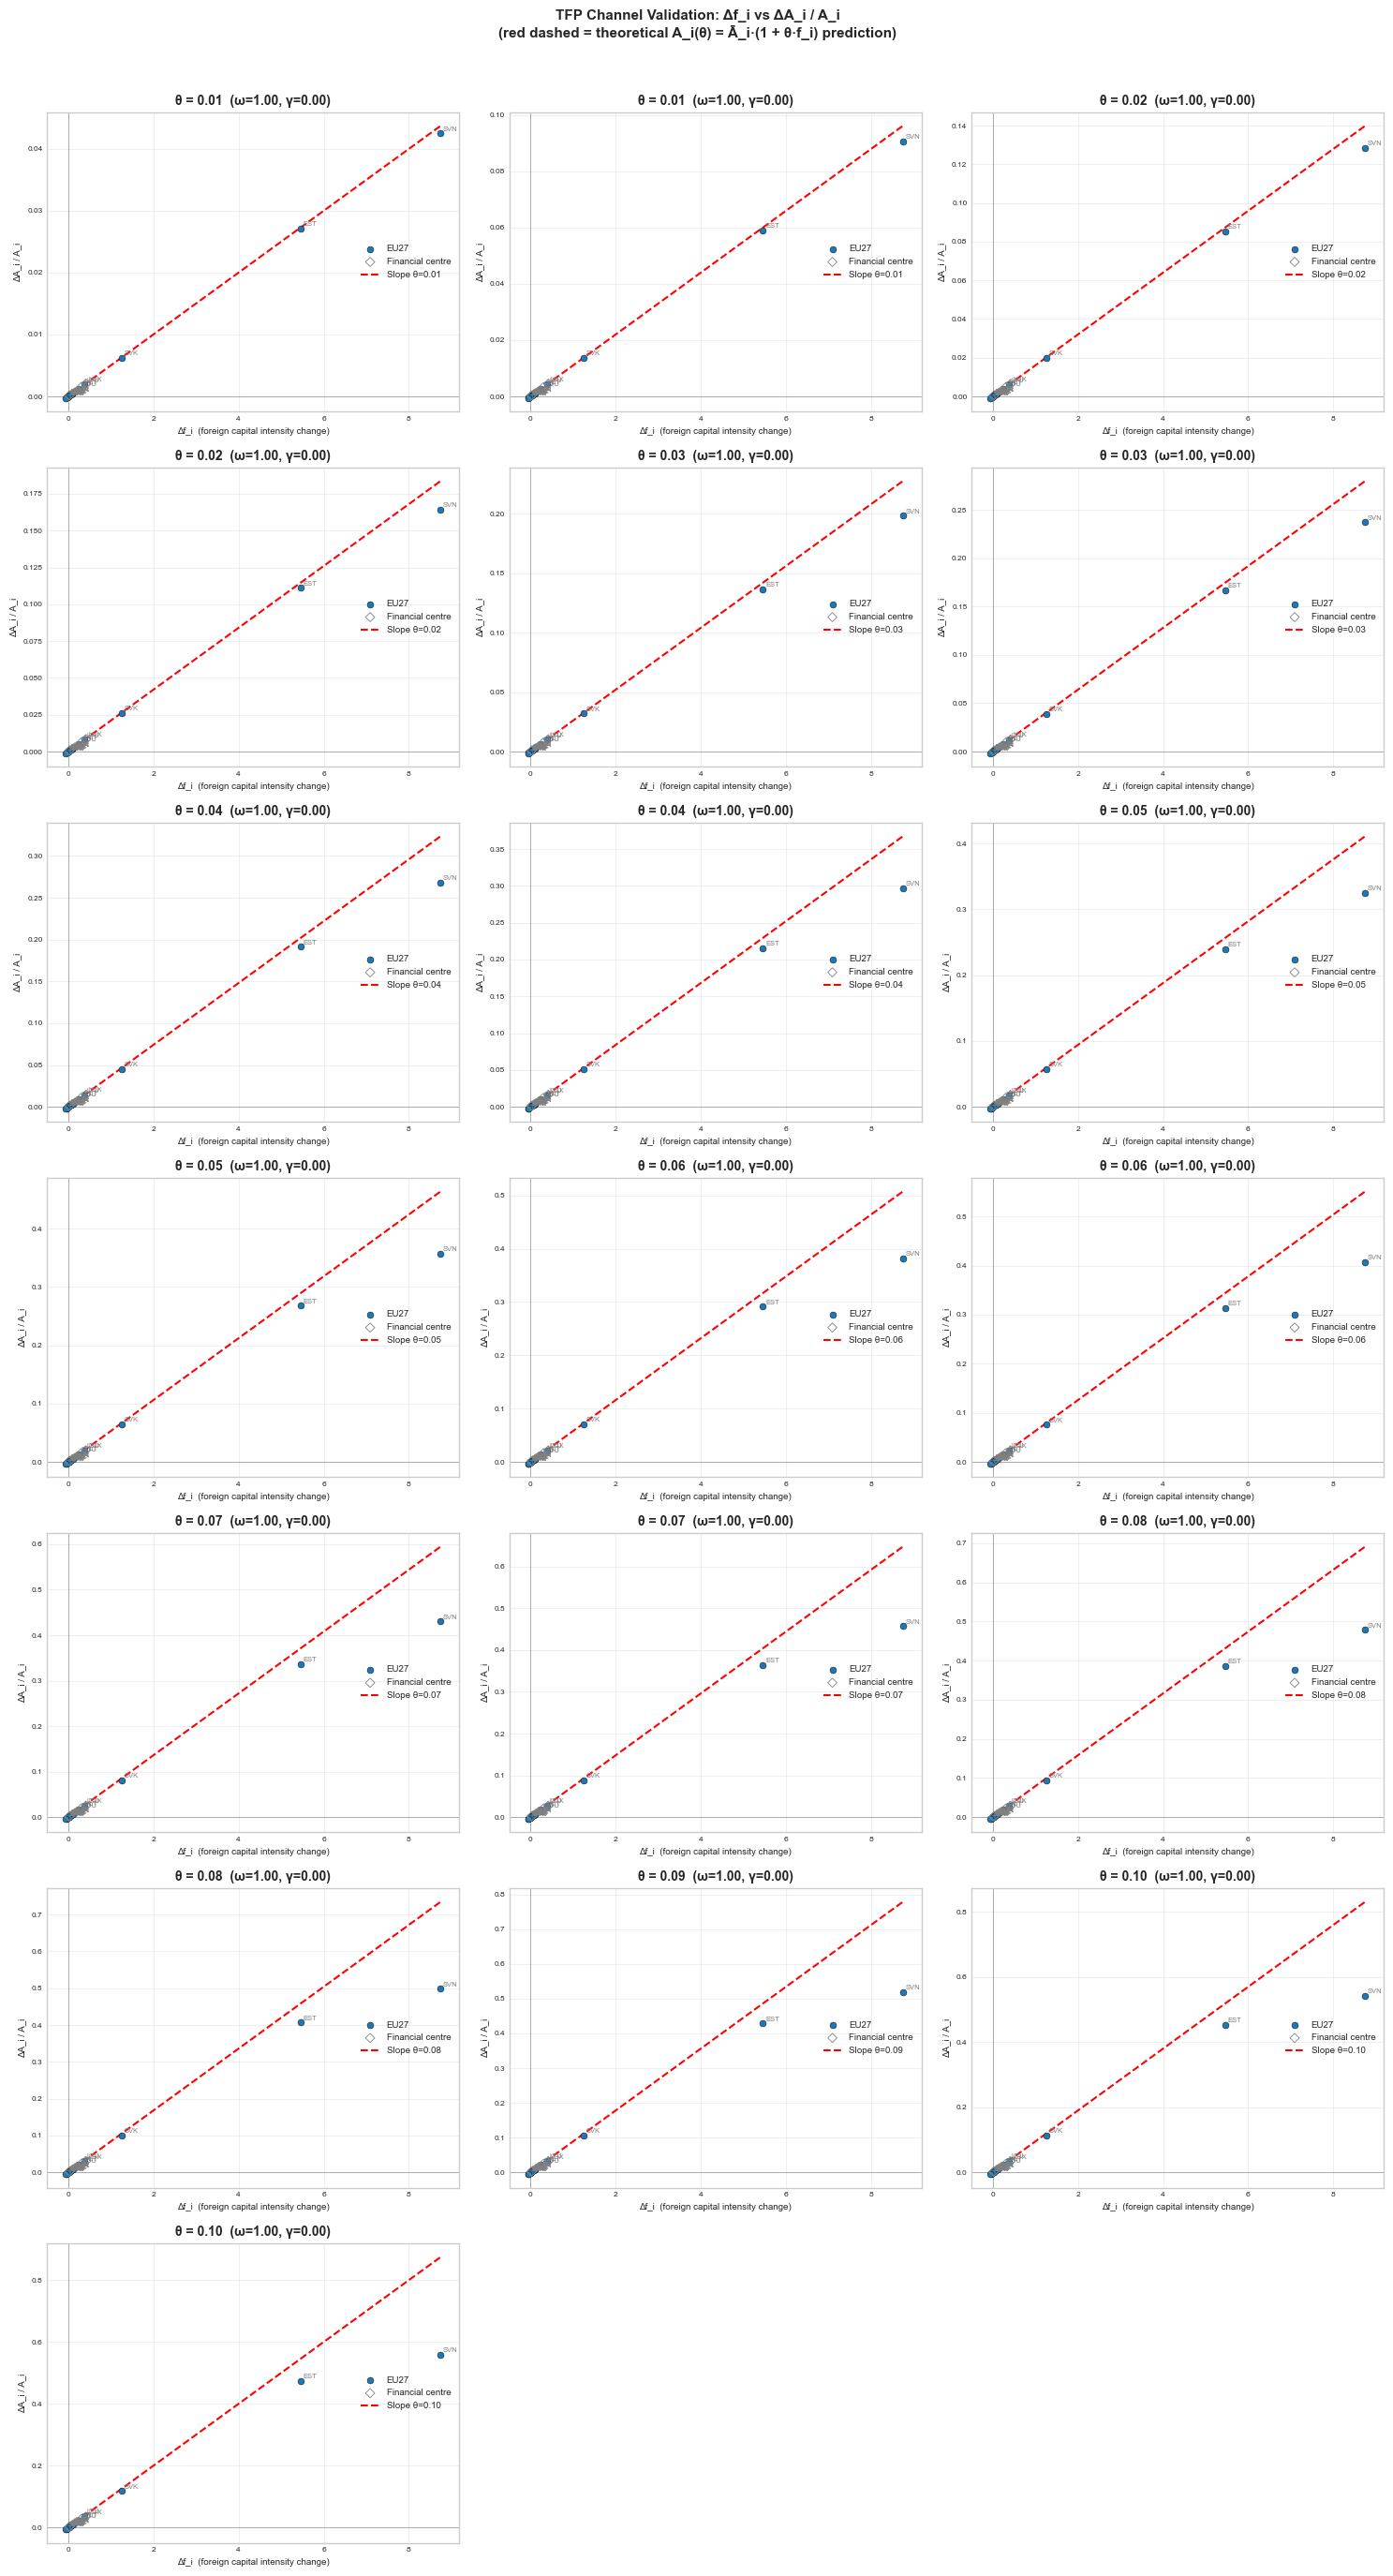

In [49]:
# Scatter: Δf_i (change in foreign capital intensity) vs ΔA_i/A_i (TFP gain)
# Should form a line through origin with slope θ — direct validation of the spillover mechanism
# One panel per (omega, gamma) combination that has non-zero θ scenarios — 3 columns, multiple rows

theta_nonzero = sorted([t for t in thetas if t > 0])
omega_fix = omegas[np.argmin(np.abs(omegas - 1.0))]
gamma_fix = gammas[np.argmin(np.abs(gammas - 0.0))]

n_panels = len(theta_nonzero)
ncols = 3
nrows = math.ceil(n_panels / ncols)

import math
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten() if nrows > 1 else np.array(axes).flatten()

for ax, theta_val in zip(axes, theta_nonzero):
    sub = df_output_country_EU[
        (df_output_country_EU['theta'] == theta_val) &
        (df_output_country_EU['omega'] == omega_fix) &
        (df_output_country_EU['gamma'] == gamma_fix)
    ].copy()
    sub['df_abs'] = sub['f_cmu'] - sub['f_baseline']

    fc_mask = sub['is_financial_ctr'] == 1
    ax.scatter(sub.loc[~fc_mask, 'df_abs'], sub.loc[~fc_mask, 'dA_pct'] / 100,
               s=25, edgecolors='black', linewidths=0.3, color='C0', zorder=3, label='EU27')
    ax.scatter(sub.loc[fc_mask, 'df_abs'], sub.loc[fc_mask, 'dA_pct'] / 100,
               s=25, marker='D', edgecolors='grey', linewidths=0.6, facecolors='none',
               zorder=3, label='Financial centre')

    # Theoretical line: ΔA/A = θ · Δf
    x_range = np.linspace(sub['df_abs'].min(), sub['df_abs'].max(), 100)
    ax.plot(x_range, theta_val * x_range, 'r--', linewidth=1.5,
            label=f'Slope θ={theta_val:.2f}')

    for _, row in sub.iterrows():
        ax.annotate(row['country'], xy=(row['df_abs'], row['dA_pct'] / 100),
                    xytext=(2, 2), textcoords='offset points', fontsize=5.5, color='grey')

    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_xlabel('Δf_i  (foreign capital intensity change)', fontsize=7)
    ax.set_ylabel('ΔA_i / A_i', fontsize=7)
    ax.set_title(f'θ = {theta_val:.2f}  (ω={omega_fix:.2f}, γ={gamma_fix:.2f})',
                 fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused panels
for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.suptitle('TFP Channel Validation: Δf_i vs ΔA_i / A_i\n'
             '(red dashed = theoretical A_i(θ) = Ā_i·(1 + θ·f_i) prediction)',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("imgs/tfp_validation_delta_f_vs_delta_A.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Contour heatmap: EU GDP gain in ω–γ space

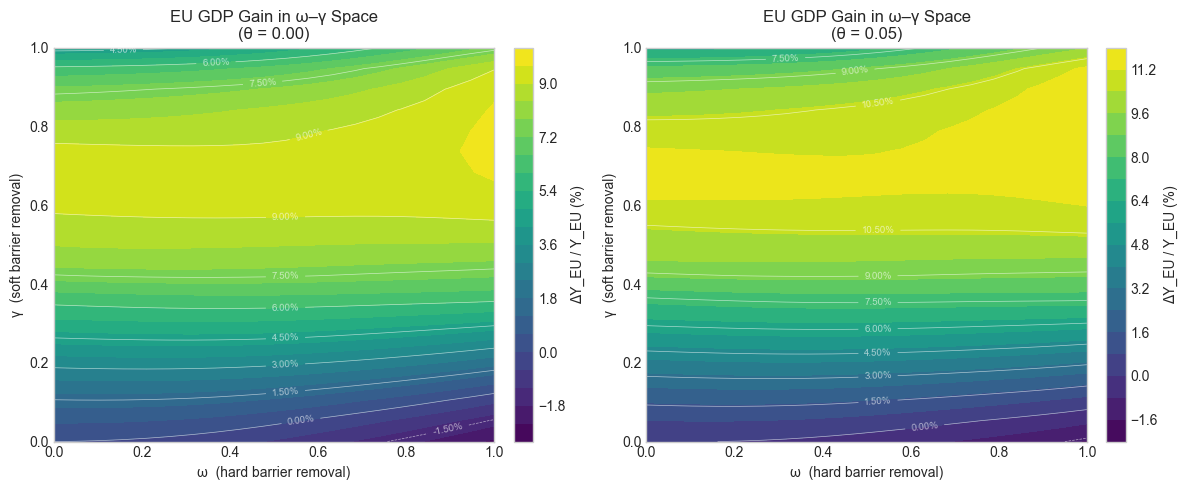

In [50]:
# Filled contour: ΔY_EU/Y_EU (%) in ω–γ space, side-by-side for θ=0 and θ≈0.05
theta_lo = thetas[np.argmin(np.abs(thetas - 0.0))]
theta_hi = thetas[np.argmin(np.abs(thetas - 0.05))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, theta_val in zip(axes, [theta_lo, theta_hi]):
    sub = df_eu_summary[df_eu_summary['theta'] == theta_val]
    pivot = sub.pivot(index='gamma', columns='omega', values='dY_EU_pct')
    omega_grid = pivot.columns.values
    gamma_grid = pivot.index.values
    Z = pivot.values

    cf = ax.contourf(omega_grid, gamma_grid, Z, levels=20, cmap=CMAP)
    cs = ax.contour(omega_grid, gamma_grid, Z, levels=10,
                    colors='white', linewidths=0.5, alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f%%')

    cb = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('ΔY_EU / Y_EU (%)')

    ax.set_xlabel('ω  (hard barrier removal)')
    ax.set_ylabel('γ  (soft barrier removal)')
    ax.set_title(f'EU GDP Gain in ω–γ Space\n(θ = {theta_val:.2f})')

plt.tight_layout()
plt.savefig("imgs/eu_gdp_gain_contour_omega_gamma.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Marginal contribution: hard vs soft barrier removal

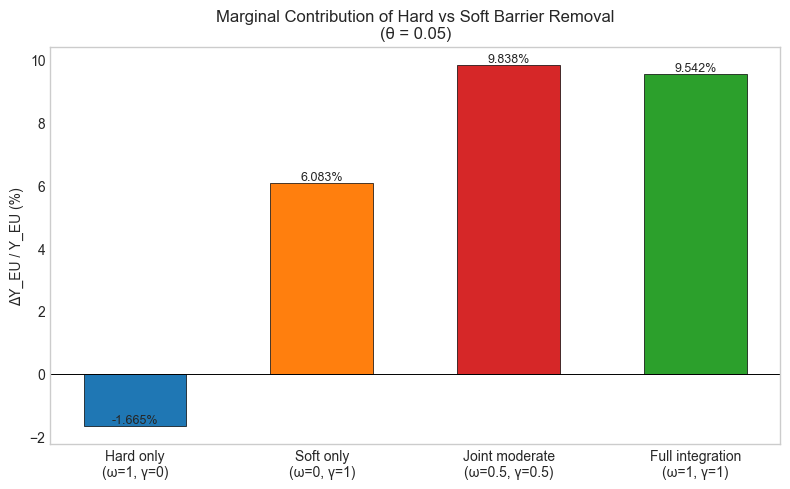

In [51]:
# Four-bar chart: EU GDP gain under four corner scenarios
# Decomposes contribution of hard (ω) vs soft (γ) barrier removal
omega_half = omegas[np.argmin(np.abs(omegas - 0.5))]
omega_full = omegas[np.argmin(np.abs(omegas - 1.0))]
gamma_half = gammas[np.argmin(np.abs(gammas - 0.5))]
gamma_full = gammas[np.argmin(np.abs(gammas - 1.0))]
theta_mid  = thetas[np.argmin(np.abs(thetas - 0.05))]

scenarios = [
    (omega_full, 0.0,         'Hard only\n(ω=1, γ=0)'),
    (0.0,         gamma_full, 'Soft only\n(ω=0, γ=1)'),
    (omega_half,  gamma_half, 'Joint moderate\n(ω=0.5, γ=0.5)'),
    (omega_full,  gamma_full, 'Full integration\n(ω=1, γ=1)'),
]

gains = []
for omega_s, gamma_s, label in scenarios:
    o = omegas[np.argmin(np.abs(omegas - omega_s))]
    g = gammas[np.argmin(np.abs(gammas - gamma_s))]
    row = df_eu_summary[
        (df_eu_summary['omega'] == o) &
        (df_eu_summary['gamma'] == g) &
        (df_eu_summary['theta'] == theta_mid)
    ]
    gains.append(row['dY_EU_pct'].values[0] if len(row) else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['C0', 'C1', 'C3', 'C2']
bars = ax.bar([s[2] for s in scenarios], gains, color=colors, width=0.55,
              edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, gains):
    if np.isfinite(val):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
                f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_ylabel('ΔY_EU / Y_EU (%)')
ax.set_title(f'Marginal Contribution of Hard vs Soft Barrier Removal\n(θ = {theta_mid:.2f})')
plt.tight_layout()
plt.savefig("imgs/marginal_contribution_hard_vs_soft.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Bilateral flow change matrix (Δa_ij heatmap)

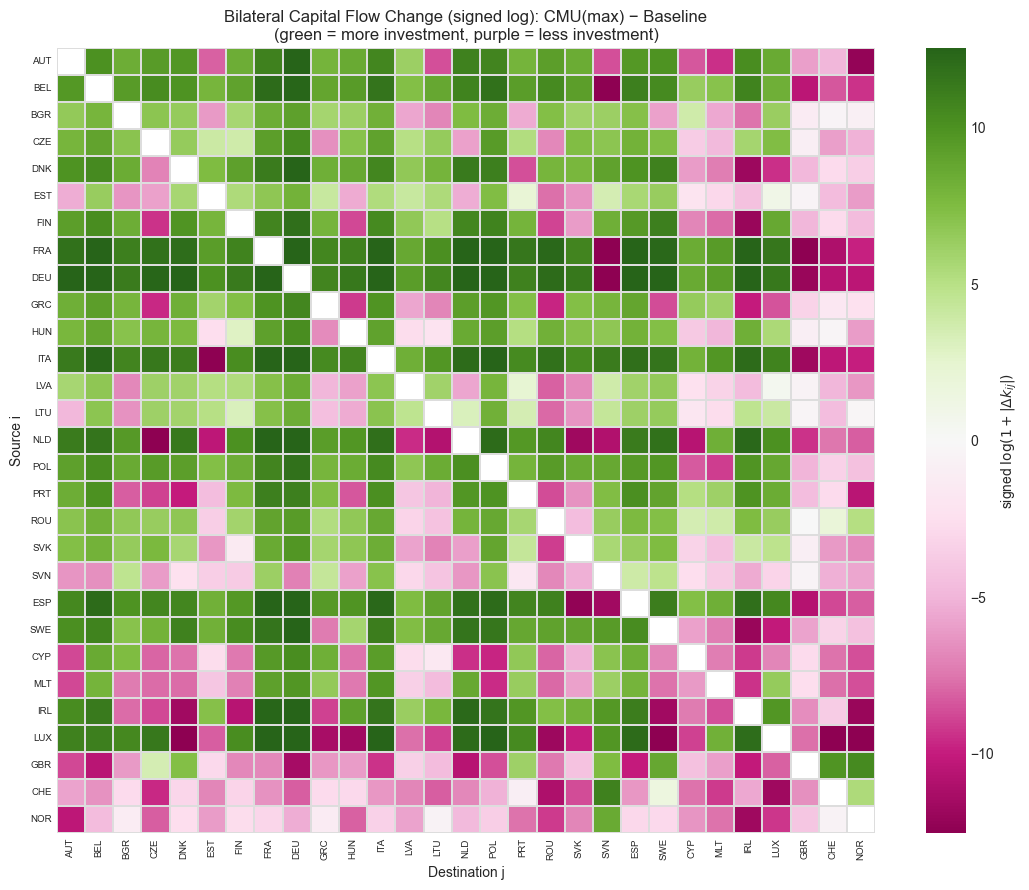

In [52]:
# Bilateral flow change matrix: Δk_ij = k_ij(CMU) - k_ij(baseline)
# Uses Portfolio_Flows sheet; compare 'max' scenario vs 'baseline'
df_flows = pd.read_excel(xls, 'Portfolio_Flows')

base_pivot = (
    df_flows[df_flows['scenario'] == 'baseline']
    .pivot(index='iso3_i', columns='iso3_j', values='k_flow')
    .reindex(index=COUNTRIES, columns=COUNTRIES)
)
cmu_pivot = (
    df_flows[df_flows['scenario'] == 'max']
    .pivot(index='iso3_i', columns='iso3_j', values='k_flow')
    .reindex(index=COUNTRIES, columns=COUNTRIES)
)

delta_matrix = cmu_pivot - base_pivot

# Set diagonal to NaN (domestic — shown elsewhere)
np.fill_diagonal(delta_matrix.values, np.nan)

# Signed log transform: sign(x) * log1p(|x|)
# (handles negatives and zeros safely)
delta_log = np.sign(delta_matrix) * np.log1p(np.abs(delta_matrix))

vlim = np.nanpercentile(np.abs(delta_log.values), 95)
norm_bi = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    delta_log,
    ax=ax,
    cmap='PiYG',
    norm=norm_bi,
    linewidths=0.3,
    linecolor='#dddddd',
    cbar_kws={'label': r'signed $\log(1+|\Delta k_{ij}|)$'},
    xticklabels=True,
    yticklabels=True,
)

ax.set_xlabel('Destination j')
ax.set_ylabel('Source i')
ax.set_title('Bilateral Capital Flow Change (signed log): CMU(max) − Baseline\n'
             '(green = more investment, purple = less investment)')
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig("imgs/bilateral_flow_change_matrix_log.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 · Portfolio composition stacked bars: domestic / EU / non-EU

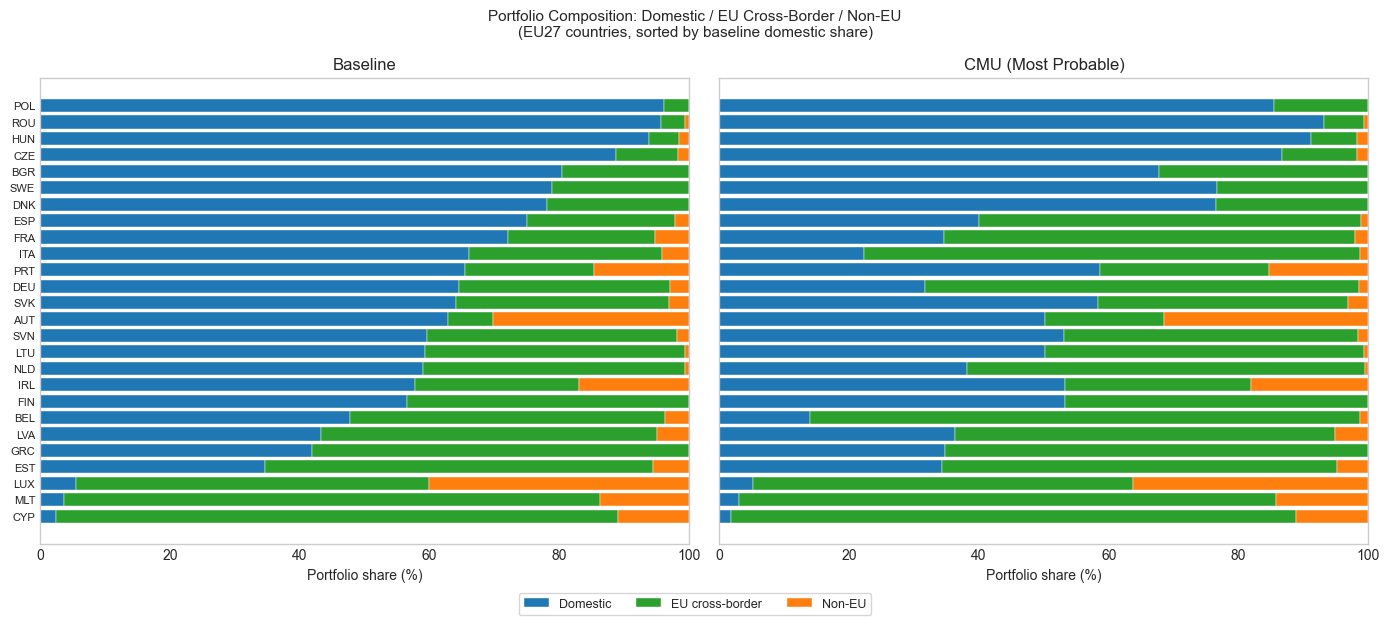

In [53]:
# Portfolio composition: share going to domestic / EU cross-border / non-EU
# Compare baseline vs most probable CMU for each EU27 country

def compute_composition(flows_df, scenario, eu27, countries):
    """Return DataFrame with columns: iso3_i, domestic, eu_xborder, non_eu"""
    sub = flows_df[flows_df['scenario'] == scenario]
    rows = []
    for country in countries:
        row_i = sub[sub['iso3_i'] == country]
        total = row_i['k_flow'].sum()
        if total == 0:
            rows.append({'country': country, 'domestic': np.nan, 'eu_xborder': np.nan, 'non_eu': np.nan})
            continue
        domestic   = row_i[row_i['iso3_j'] == country]['k_flow'].sum()
        eu_xborder = row_i[(row_i['iso3_j'] != country) & (row_i['iso3_j'].isin(eu27))]['k_flow'].sum()
        non_eu     = row_i[~row_i['iso3_j'].isin(eu27)]['k_flow'].sum()
        rows.append({
            'country':    country,
            'domestic':   domestic   / total * 100,
            'eu_xborder': eu_xborder / total * 100,
            'non_eu':     non_eu     / total * 100,
        })
    return pd.DataFrame(rows)

comp_base = compute_composition(df_flows, 'baseline',      EU27, EU27)
comp_cmu  = compute_composition(df_flows, 'most_probable', EU27, EU27)

# Sort by domestic share (baseline) descending
order = comp_base.sort_values('domestic', ascending=True)['country'].tolist()
comp_base = comp_base.set_index('country').reindex(order)
comp_cmu  = comp_cmu.set_index('country').reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colors_comp = {'domestic': 'C0', 'eu_xborder': 'C2', 'non_eu': 'C1'}
labels_comp = {'domestic': 'Domestic', 'eu_xborder': 'EU cross-border', 'non_eu': 'Non-EU'}

handles, legend_labels = [], []
for ax, df_comp, title in zip(axes, [comp_base, comp_cmu], ['Baseline', f'CMU (Most Probable)']):
    y = np.arange(len(df_comp))
    left = np.zeros(len(df_comp))
    for key in ['domestic', 'eu_xborder', 'non_eu']:
        vals = df_comp[key].fillna(0).values
        bar = ax.barh(y, vals, left=left, color=colors_comp[key],
                      label=labels_comp[key], edgecolor='white', linewidth=0.3)
        if ax == axes[0]:
            handles.append(bar)
            legend_labels.append(labels_comp[key])
        left += vals
    ax.set_yticks(y)
    ax.set_yticklabels(df_comp.index, fontsize=8)
    ax.set_xlabel('Portfolio share (%)')
    ax.set_title(title)
    ax.set_xlim(0, 100)

fig.legend(handles, legend_labels, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.suptitle('Portfolio Composition: Domestic / EU Cross-Border / Non-EU\n(EU27 countries, sorted by baseline domestic share)', fontsize=11)
plt.tight_layout()
plt.savefig("imgs/portfolio_composition_domestic_eu_noneu.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 · Winners / losers bar chart

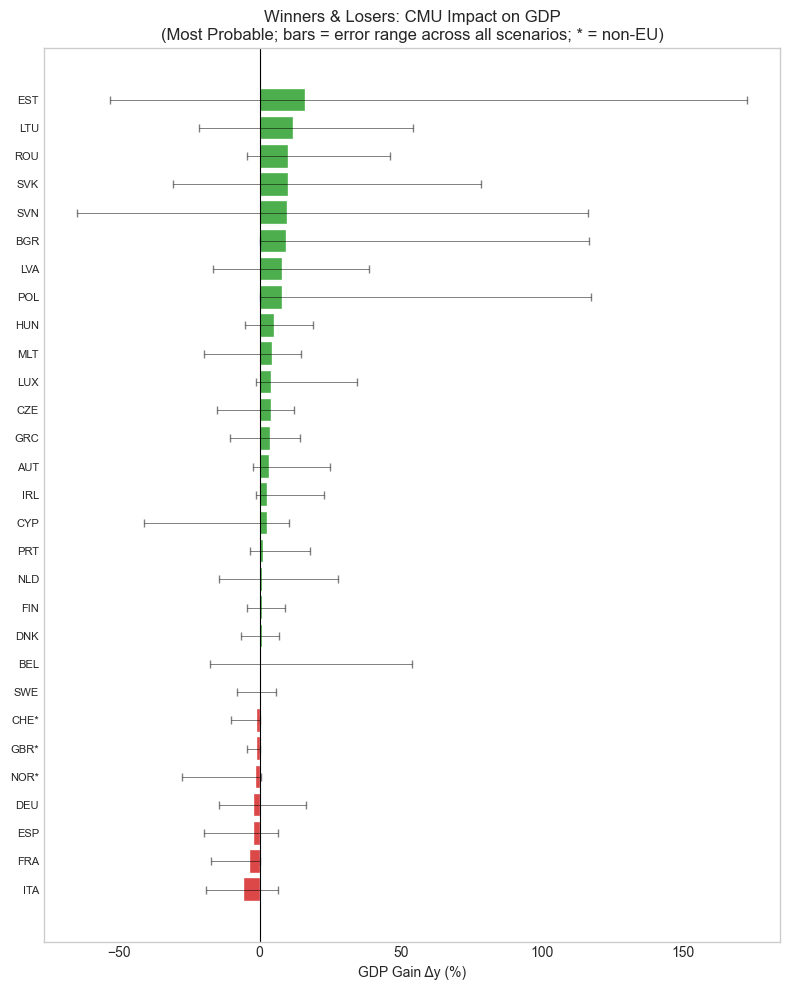

In [54]:
# Horizontal bar chart of GDP gain (%) per country — most probable CMU
# Green = winner, red = loser, with error bars showing full (min,max) range

# Most probable scenario
df_win = df_output_country[
    (df_output_country['theta'] == CMU_THETA) &
    (df_output_country['omega'] == CMU_OMEGA) &
    (df_output_country['gamma'] == CMU_GAMMA)
][['country', 'dy_pct', 'in_EU27']].copy()

# Full range across all scenarios per country
df_range = (
    df_output_country
    .groupby('country')['dy_pct']
    .agg(['min', 'max'])
    .reset_index()
)
df_win = df_win.merge(df_range, on='country')
df_win = df_win.sort_values('dy_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 10))
y = np.arange(len(df_win))

colors_win = ['#d62728' if v < 0 else '#2ca02c' for v in df_win['dy_pct']]
ax.barh(y, df_win['dy_pct'], color=colors_win, edgecolor='white', linewidth=0.3, alpha=0.85)

# Error bars: range across all ω, γ, θ scenarios
xerr_lo = df_win['dy_pct'] - df_win['min']
xerr_hi = df_win['max'] - df_win['dy_pct']
ax.errorbar(df_win['dy_pct'], y,
            xerr=[xerr_lo, xerr_hi],
            fmt='none', color='black', linewidth=0.7, capsize=3, alpha=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{row['country']}{'*' if row['in_EU27'] == 0 else ''}" for _, row in df_win.iterrows()],
    fontsize=8
)
ax.set_xlabel('GDP Gain Δy (%)')
ax.set_title(f'Winners & Losers: CMU Impact on GDP\n'
             f'(Most Probable; '
             f'bars = error range across all scenarios; * = non-EU)')
plt.tight_layout()
plt.savefig("imgs/winners_losers_gdp_gain.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Distribution of country-level GDP gains across all scenarios

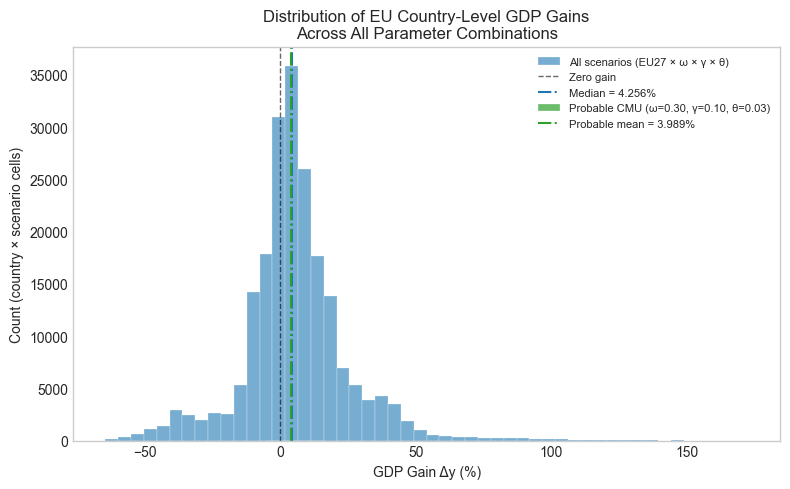

Share of (country, scenario) cells with positive GDP gain: 65.8%


In [63]:
# Histogram of dy_pct across all EU27 countries × all (ω, γ, θ) scenarios
# Annotated with the most probable scenario mean

all_gains = df_output_country_EU['dy_pct'].dropna().values
prob_gains = df_output_country_EU[
    (df_output_country_EU['theta'] == CMU_THETA) &
    (df_output_country_EU['omega'] == CMU_OMEGA) &
    (df_output_country_EU['gamma'] == CMU_GAMMA)
]['dy_pct'].dropna().values

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_gains, bins=50, color='C0', alpha=0.6, edgecolor='white',
        linewidth=0.3, label='All scenarios (EU27 × ω × γ × θ)')
ax.axvline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6, label='Zero gain')
ax.axvline(np.median(all_gains), color='C0', linewidth=1.5, linestyle='-.',
           label=f'Median = {np.median(all_gains):.3f}%')

# Overlay most probable scenario as rug / density
ax.hist(prob_gains, bins=20, color='C2', alpha=0.7, edgecolor='white',
        linewidth=0.3, label=f'Probable CMU (ω={_CMU_OMEGA:.2f}, γ={_CMU_GAMMA:.2f}, θ={_CMU_THETA:.2f})')
ax.axvline(np.mean(prob_gains), color='C2', linewidth=1.5, linestyle='-.',
           label=f'Probable mean = {np.mean(prob_gains):.3f}%')

ax.set_xlabel('GDP Gain Δy (%)')
ax.set_ylabel('Count (country × scenario cells)')
ax.set_title('Distribution of EU Country-Level GDP Gains\nAcross All Parameter Combinations')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("imgs/distribution_eu_gdp_gains.png", dpi=150, bbox_inches="tight")
plt.show()

pct_pos = (all_gains > 0).mean() * 100
print(f"Share of (country, scenario) cells with positive GDP gain: {pct_pos:.1f}%")


## 1–2 · MPK convergence: σ(MPK) vs ω and before/after bar chart

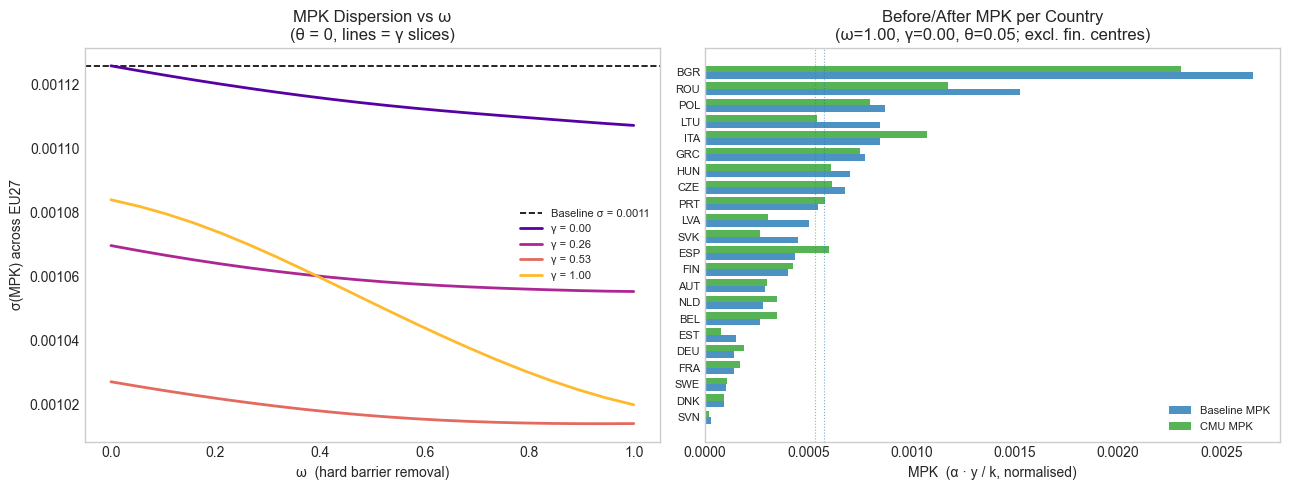

In [56]:
# MPK convergence: σ(MPK) vs ω, one line per γ slice
# Uses EU_Summary sigma_mpk_cmu / sigma_mpk_baseline columns
# θ=0 so that TFP doesn't confound the MPK convergence story

theta_zero = thetas[np.argmin(np.abs(thetas - 0.0))]
df_sigma = df_eu_summary[df_eu_summary['theta'] == theta_zero].copy()

gamma_slices = sorted(df_sigma['gamma'].unique())
# Pick a manageable subset to avoid overplotting
gamma_pick = [gamma_slices[0],
              gamma_slices[len(gamma_slices) // 4],
              gamma_slices[len(gamma_slices) // 2],
              gamma_slices[-1]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: σ(MPK) as function of ω ────────────────────────────
ax = axes[0]
cmap_g = plt.cm.plasma(np.linspace(0.15, 0.85, len(gamma_pick)))
sigma_base_val = df_sigma[df_sigma['omega'] == omegas[0]]['sigma_mpk_baseline'].mean()
ax.axhline(sigma_base_val, color='black', linewidth=1.2, linestyle='--',
           label=f'Baseline σ = {sigma_base_val:.4f}')
for color, gval in zip(cmap_g, gamma_pick):
    sub = df_sigma[df_sigma['gamma'] == gval].sort_values('omega')
    ax.plot(sub['omega'], sub['sigma_mpk_cmu'], linewidth=2, color=color,
            label=f'γ = {gval:.2f}')
ax.set_xlabel('ω  (hard barrier removal)')
ax.set_ylabel('σ(MPK) across EU27')
ax.set_title('MPK Dispersion vs ω\n(θ = 0, lines = γ slices)')
ax.legend(fontsize=8)

# ── Right: before/after MPK bar chart — full vs no integration ─
ax = axes[1]
theta_hi2 = thetas[np.argmin(np.abs(thetas - 0.05))]
omega_full2 = omegas[np.argmin(np.abs(omegas - 1.0))]
gamma_zero2 = gammas[np.argmin(np.abs(gammas - 0.0))]

df_mpk_ctry = df_output_country_EU[
    (df_output_country_EU['theta'] == theta_hi2) &
    (df_output_country_EU['omega'] == omega_full2) &
    (df_output_country_EU['gamma'] == gamma_zero2)
][['country', 'mpk_baseline', 'mpk_cmu']].copy()
df_mpk_ctry = df_mpk_ctry[~df_mpk_ctry['country'].isin(['IRL','LUX','CYP','MLT'])]
df_mpk_ctry = df_mpk_ctry.sort_values('mpk_baseline', ascending=True).reset_index(drop=True)

y2 = np.arange(len(df_mpk_ctry))
ax.barh(y2 - 0.2, df_mpk_ctry['mpk_baseline'], height=0.4,
        color='C0', alpha=0.8, label='Baseline MPK')
ax.barh(y2 + 0.2, df_mpk_ctry['mpk_cmu'], height=0.4,
        color='C2', alpha=0.8, label='CMU MPK')
ax.set_yticks(y2)
ax.set_yticklabels(df_mpk_ctry['country'], fontsize=8)
ax.set_xlabel('MPK  (α · y / k, normalised)')
ax.set_title(f'Before/After MPK per Country\n(ω={omega_full2:.2f}, γ={gamma_zero2:.2f}, θ={theta_hi2:.2f}; excl. fin. centres)')
ax.axvline(df_mpk_ctry['mpk_baseline'].mean(), color='C0', linewidth=0.8, linestyle=':', alpha=0.6)
ax.axvline(df_mpk_ctry['mpk_cmu'].mean(), color='C2', linewidth=0.8, linestyle=':', alpha=0.6)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("imgs/mpk_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## 12 · Robustness: η sensitivity fan — EU GDP gain vs ω

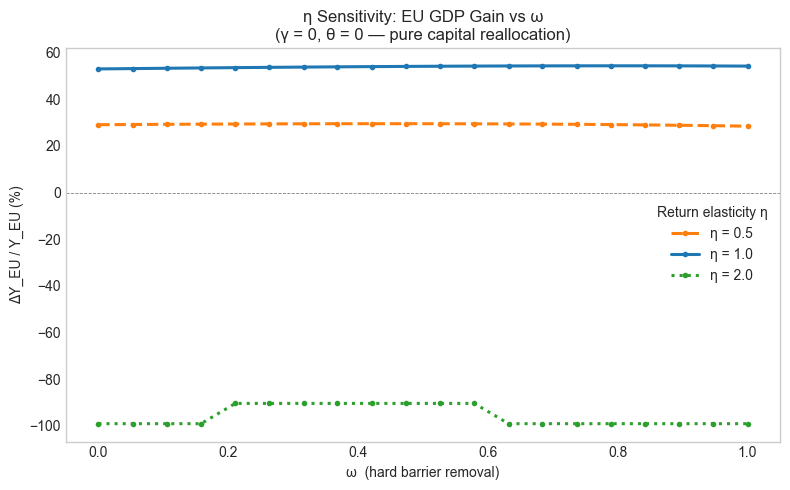

In [57]:
# η sensitivity fan: EU GDP gain vs ω for η = 0.5, 1.0, 2.0
# Fixed: γ = 0, θ = 0  →  isolates pure capital reallocation channel
# Uses the Robustness sheet produced by run_model_variant_endo

rob = df_robustness.copy()
rob.columns = rob.columns.str.strip()

# γ = 0 slice
gamma_col = 'gamma'
rob_slice = rob[rob[gamma_col] == rob[gamma_col].min()].copy()

# θ = 0 slice
theta_col = 'theta'
rob_slice = rob_slice[rob_slice[theta_col] == rob_slice[theta_col].min()].copy()

eta_vals = sorted(rob_slice['eta'].unique())
dY_col   = 'ΔY_EU/Y_EU (%)'

fig, ax = plt.subplots(figsize=(8, 5))
styles = {0.5: ('--', 'C1'), 1.0: ('-', 'C0'), 2.0: (':', 'C2')}

for eta_val in eta_vals:
    sub = rob_slice[rob_slice['eta'] == eta_val].sort_values('omega')
    ls, col = styles.get(eta_val, ('-', 'grey'))
    ax.plot(sub['omega'], sub[dY_col], linewidth=2.2, linestyle=ls,
            color=col, label=f'η = {eta_val}', marker='o', markersize=3)

ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.5)
ax.set_xlabel('ω  (hard barrier removal)')
ax.set_ylabel('ΔY_EU / Y_EU (%)')
ax.set_title('η Sensitivity: EU GDP Gain vs ω\n(γ = 0, θ = 0 — pure capital reallocation)')
ax.legend(title='Return elasticity η')
plt.tight_layout()
plt.savefig("imgs/eta_sensitivity_eu_gdp_vs_omega.png", dpi=150, bbox_inches="tight")
plt.show()


## 13 · Robustness heatmap: η × θ at full integration (ω=1, γ=0)

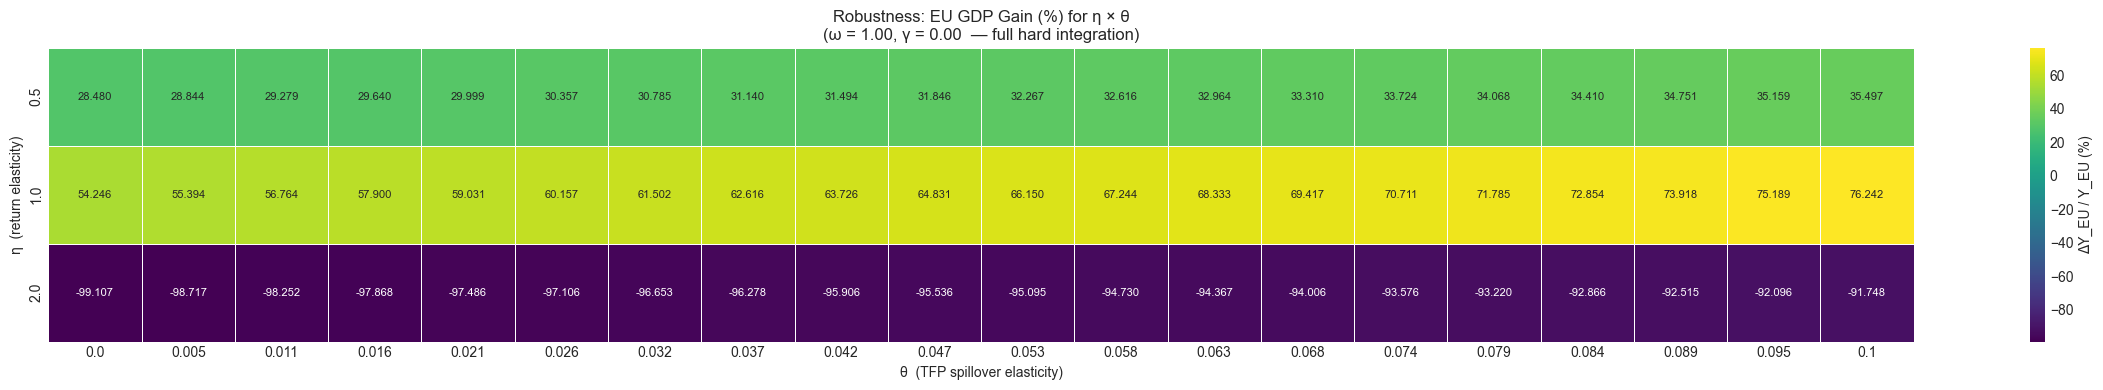

In [58]:
# Robustness heatmap: EU GDP gain for all combinations of η × θ
# Fixed: ω = 1.0 (max hard integration), γ = 0.0
# Shows how sensitive the result is to the two key structural assumptions

omega_max = rob['omega'].max()
gamma_min = rob['gamma'].min()

rob_hm = rob[
    (np.abs(rob['omega'] - omega_max) < 1e-6) &
    (np.abs(rob['gamma'] - gamma_min) < 1e-6)
].copy()

pivot_rob = rob_hm.pivot_table(index='eta', columns='theta', values=dY_col)

n_cols = pivot_rob.shape[1]
n_rows = pivot_rob.shape[0]
fig, ax = plt.subplots(figsize=(max(9, n_cols * 1.2), max(4, n_rows * 0.9)))
sns.heatmap(
    pivot_rob,
    ax=ax,
    cmap=CMAP,
    annot=True,
    fmt='.3f',
    annot_kws={'size': 8},
    linewidths=0.4,
    cbar_kws={'label': 'ΔY_EU / Y_EU (%)'},
)
ax.set_xlabel('θ  (TFP spillover elasticity)')
ax.set_ylabel('η  (return elasticity)')
ax.set_title(f'Robustness: EU GDP Gain (%) for η × θ\n'
             f'(ω = {omega_max:.2f}, γ = {gamma_min:.2f}  — full hard integration)')
plt.tight_layout()
plt.savefig("imgs/robustness_heatmap_eta_theta.png", dpi=150, bbox_inches="tight")
plt.show()


## 14 · Tornado chart: parameter uncertainty contribution

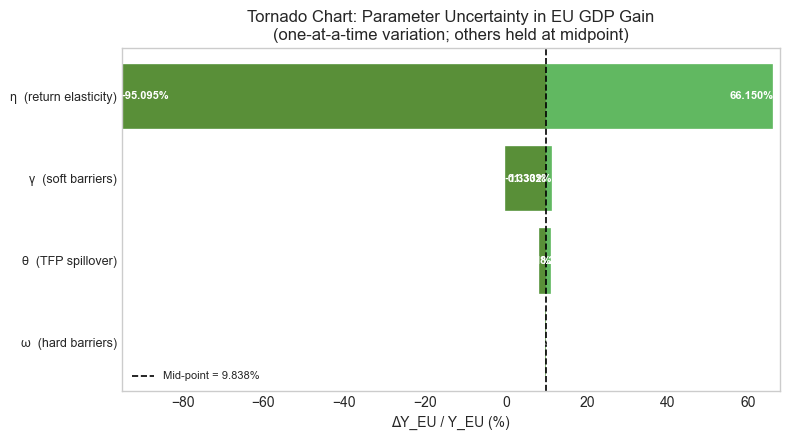

In [59]:
# Tornado chart: how much of the range in EU GDP gain comes from each parameter?
# Method: vary one parameter at a time while holding others at their midpoint.
# Midpoints: ω=0.5, γ=0.5, θ=0.05, η=1.0

mid_omega = omegas[np.argmin(np.abs(omegas - 0.5))]
mid_gamma = gammas[np.argmin(np.abs(gammas - 0.5))]
mid_theta = thetas[np.argmin(np.abs(thetas - 0.05))]
mid_eta   = 1.0

# ── ω range (γ=mid, θ=mid) ──────────────────────────────────
sub_omega = df_eu_summary[
    (df_eu_summary['gamma'] == mid_gamma) &
    (df_eu_summary['theta'] == mid_theta)
]
omega_min_gain = sub_omega['dY_EU_pct'].min()
omega_max_gain = sub_omega['dY_EU_pct'].max()

# ── γ range (ω=mid, θ=mid) ──────────────────────────────────
sub_gamma = df_eu_summary[
    (df_eu_summary['omega'] == mid_omega) &
    (df_eu_summary['theta'] == mid_theta)
]
gamma_min_gain = sub_gamma['dY_EU_pct'].min()
gamma_max_gain = sub_gamma['dY_EU_pct'].max()

# ── θ range (ω=mid, γ=mid) ──────────────────────────────────
sub_theta = df_eu_summary[
    (df_eu_summary['omega'] == mid_omega) &
    (df_eu_summary['gamma'] == mid_gamma)
]
theta_min_gain = sub_theta['dY_EU_pct'].min()
theta_max_gain = sub_theta['dY_EU_pct'].max()

# ── η range (ω=1, γ=0, θ=mid) ───────────────────────────────
rob_eta = rob[
    (np.abs(rob['omega'] - omega_max) < 1e-6) &
    (np.abs(rob['gamma'] - gamma_min) < 1e-6) &
    (np.abs(rob['theta'] - mid_theta) < 1e-6)
]
eta_min_gain = rob_eta[dY_col].min() if len(rob_eta) else np.nan
eta_max_gain = rob_eta[dY_col].max() if len(rob_eta) else np.nan

tornado_data = pd.DataFrame([
    {'param': 'ω  (hard barriers)', 'lo': omega_min_gain, 'hi': omega_max_gain},
    {'param': 'γ  (soft barriers)', 'lo': gamma_min_gain, 'hi': gamma_max_gain},
    {'param': 'θ  (TFP spillover)', 'lo': theta_min_gain, 'hi': theta_max_gain},
    {'param': 'η  (return elasticity)', 'lo': eta_min_gain, 'hi': eta_max_gain},
])
tornado_data['range'] = tornado_data['hi'] - tornado_data['lo']
tornado_data = tornado_data.sort_values('range', ascending=True)

base_val = df_eu_summary[
    (df_eu_summary['omega'] == mid_omega) &
    (df_eu_summary['gamma'] == mid_gamma) &
    (df_eu_summary['theta'] == mid_theta)
]['dY_EU_pct'].values[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(tornado_data))

for i, (_, row) in enumerate(tornado_data.iterrows()):
    lo, hi = row['lo'] - base_val, row['hi'] - base_val
    ax.barh(i, lo, left=base_val, color='#d62728', alpha=0.75,
            edgecolor='white', linewidth=0.3)
    ax.barh(i, hi - lo, left=base_val + lo, color='#2ca02c', alpha=0.75,
            edgecolor='white', linewidth=0.3)
    # Place labels just inside the bar ends to avoid clipping
    ax.text(row['lo'] + 0.001, i, f'{row["lo"]:.3f}%', va='center', ha='left',  fontsize=8, color='white', fontweight='bold')
    ax.text(row['hi'] - 0.001, i, f'{row["hi"]:.3f}%', va='center', ha='right', fontsize=8, color='white', fontweight='bold')

ax.axvline(base_val, color='black', linewidth=1.2, linestyle='--', label=f'Mid-point = {base_val:.3f}%')
ax.set_yticks(y)
ax.set_yticklabels(tornado_data['param'], fontsize=9)
ax.set_xlabel('ΔY_EU / Y_EU (%)')
ax.set_title('Tornado Chart: Parameter Uncertainty in EU GDP Gain\n(one-at-a-time variation; others held at midpoint)')
ax.legend(fontsize=8)
ax.margins(x=0.01)
plt.tight_layout()
plt.savefig("imgs/tornado_parameter_uncertainty.png", dpi=150, bbox_inches="tight")
plt.show()